# Benchmarking sample representation methods on COVID-19 PBMCs


## The problem

We'll work with the [COMBAT dataset](https://www.kaggle.com/datasets/shitovvladimir/a-blood-atlas-of-covid-19-combat-preprocessed) {cite}`ahern2022blood`: ~140 PBMC samples from COVID-19 patients and healthy donors, processed across multiple hospitals (`Source` / `Institute`) and sequencing pools (`Pool_ID`), with clinical outcomes spanning healthy → mild → severe → critical → death within 28 days.

We want a sample-level representation that lets us answer two questions in one go:

1. **Does it capture the clinical signal?** Patients with worse outcomes should sit closer to each other than to healthy donors.
2. **Is it robust to technical variation?** Whether a sample came from hospital A or hospital B, or pool 1 vs pool 2, should be (almost) invisible — those are technical artefacts, not biology.

These two requirements are in tension. A representation that scores high on (1) by accidentally encoding which institute ran the experiment is no use. In this notebook we'll run several `patpy` methods, evaluate each against both criteria, and end with a single comparison table.


## What we'll do

Starting from the simplest representation (pseudobulk) and working up to deep, batch-aware methods (MrVI, scPoli), we'll:

1. Set up COMBAT and extract sample-level metadata.
2. Run each method through the same `patpy` lifecycle (`prepare_anndata` → `calculate_distance_matrix` → `plot_embedding` → `evaluate_representation`).
3. Score every method against the same set of covariates with kNN classification / regression and with a trajectory-correlation score on `Outcome`.
4. Compare side-by-side in one table, then briefly run the same workflow on a different dataset (HLCA) to show it ports.

### Installation

Most of what we use ships with the base install (`pip install patpy`). The deep methods need extras (and ideally a CUDA GPU):

```bash
pip install patpy[pilot,mrvi,scpoli,diffusionemd]
pip install mofapy2  # MOFA isn't behind an extra yet
```

GloScope's R version has its own setup; see the dedicated tutorial linked at the end. A reproducible conda env is at [`envs/benchmark_tutorial.yaml`](https://github.com/lueckenlab/patpy/blob/main/envs/benchmark_tutorial.yaml).


## Import packages

In [1]:
import ehrapy as ep
import pandas as pd
import scanpy as sc
import patpy
import seaborn as sns
from plottable import ColumnDefinition, Table
from plottable.cmap import normed_cmap
from plottable.plots import bar
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [2]:
patpy.__version__

'0.16.5'

## Read the data

We'll start with the [COMBAT dataset](https://www.kaggle.com/datasets/shitovvladimir/a-blood-atlas-of-covid-19-combat-preprocessed). {cite}`ahern2022blood` This dataset contains 783k peripheral blood mononuclear cells from 140 samples of COVID-19 patients and healthy donors. A preprocessed version of COMBAT dataset can be easily loaded with `patpy`:

In [3]:
adata = patpy.datasets.combat()
adata

AnnData object with n_obs × n_vars = 783677 × 3000
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_HC

Set the `PATPY_NB_TEST` environment variable to a non-empty value before launching the kernel to run a quick smoke-test on a tiny subset (15 donors, 10% of cells per donor with a floor of 10). Otherwise the notebook runs on the full ~783k cells / ~140 donors.


In [4]:
import os
import numpy as np

if os.environ.get("PATPY_NB_TEST"):
    rng = np.random.default_rng(67)
    sample_ids = adata.obs["scRNASeq_sample_ID"].unique()
    test_donors = rng.choice(sample_ids, size=min(15, len(sample_ids)), replace=False)
    adata = adata[adata.obs["scRNASeq_sample_ID"].isin(test_donors)].copy()
    adata = patpy.pp.subsample(
        adata,
        obs_category_col="scRNASeq_sample_ID",
        min_samples_per_category=10,
        fraction=0.1,
    )
    print(f"PATPY_NB_TEST: subsampled to {adata.n_obs} cells across "
          f"{adata.obs['scRNASeq_sample_ID'].nunique()} donors")


Set columns containing sample IDs, cell types and `.obs` columns containing sample-level metadata:

In [5]:
sample_key = "scRNASeq_sample_ID"
cell_type_key = "cell_type"
sample_level_columns = ["Source", "Outcome", "Death28", "Institute", "Pool_ID", "Age"]

# Per-method runtimes accumulated as we go; later cells aggregate per dataset.
runtimes = {"combat": {}}
dataset_summaries = {}


Currently, there is no such columns as "cell_type" in the data. But cell types are stored in the `Annotation_major_subset` column. Let's rename it to `cell_type` for better readability.

In [6]:
adata.obs.rename(columns={"Annotation_major_subset": cell_type_key}, inplace=True)

## Store metadata and calculate QC metrics

We want to evaluate how different sample representation methods preserve the useful information and whether they are affected by batch effects. To do that, we need to extract sample-level metadata and aggregate cell-level QC metrics. All of it can be conveniently done with `patpy` preprocessing module:

In [7]:
metadata = patpy.pp.extract_metadata(adata, sample_key, sample_level_columns)
metadata

,Source,Outcome,Death28,Institute,Pool_ID,Age
scRNASeq_sample_ID,,,,,,
S00109-Ja001E-PBCa,COVID_SEV,2.0,0,Oxford,gPlexA,5.0
S00112-Ja003E-PBCa,COVID_MILD,5.0,0,Oxford,gPlexA,5.0
S00005-Ja005E-PBCa,COVID_CRIT,2.0,0,Oxford,gPlexA,7.0
S00061-Ja003E-PBCa,COVID_SEV,4.0,0,Oxford,gPlexA,5.0
S00056-Ja003E-PBCa,COVID_SEV,3.0,0,Oxford,gPlexA,7.0
...,...,...,...,...,...,...
S00065-Ja003E-PBCa,COVID_CRIT,2.0,0,Oxford,gPlexK,5.0
S00048-Ja003E-PBCa,COVID_SEV,4.0,0,Oxford,gPlexK,7.0
G05112-Ja005E-PBCa,COVID_HCW_MILD,6.0,0,Oxford,gPlexK,4.0


This function will aggregate cell level QC metrics per sample. By default, median aggregation is used. Make sure the columns you want to aggregate are in `adata.obs`! Here, we'll use number of genes per cell, percentage of mitochondrial genes, and doublet score:

In [8]:
cell_qc_metadata = patpy.pp.calculate_cell_qc_metrics(
    adata, sample_key=sample_key, cell_qc_vars=["QC_ngenes", "QC_pct_mitochondrial", "QC_scrub_doublet_scores"]
)
cell_qc_metadata

,median_QC_ngenes,median_QC_pct_mitochondrial,median_QC_scrub_doublet_scores
scRNASeq_sample_ID,,,
G05061-Ja005E-PBCa,1107.0,3.011159,0.050648
G05064-Ja005E-PBCa,975.0,1.332430,0.060894
G05073-Ja005E-PBCa,1141.0,2.422559,0.044530
G05077-Ja005E-PBCa,1125.0,2.946723,0.048490
G05078-Ja005E-PBCa,999.0,2.825308,0.052783
...,...,...,...
U00607-Ua005E-PBUa,1827.0,2.982509,0.043323
U00613-Ua005E-PBUa,1251.5,2.053083,0.036956
U00617-Ua005E-PBUa,1410.5,3.886215,0.057906


In [9]:
n_genes_metadata = patpy.pp.calculate_n_cells_per_sample(adata, sample_key)
n_genes_metadata

,n_cells
scRNASeq_sample_ID,
S00052-Ja005E-PBCa,13918
H00054-Ha001E-PBGa,10938
H00067-Ha001E-PBGa,10781
N00023-Ja001E-PBGa,10484
H00053-Ha001E-PBGa,10458
...,...
U00607-Ua005E-PBUa,1021
U00613-Ua005E-PBUa,970
U00701-Ua005E-PBUa,872


Additionally, let's compute cell type proportions to see if they impact sample representations:

In [10]:
composition_metadata = patpy.pp.calculate_compositional_metrics(adata, sample_key, [cell_type_key], normalize_to=100)
composition_metadata

cell_type,cell_type_B,cell_type_CD4,cell_type_CD8,cell_type_DC,cell_type_DN,cell_type_DP,cell_type_GDT,cell_type_HSC,cell_type_MAIT,cell_type_Mast,cell_type_NK,cell_type_PB,cell_type_PLT,cell_type_RET,cell_type_cMono,cell_type_iNKT,cell_type_ncMono
scRNASeq_sample_ID,,,,,,,,,,,,,,,,,
G05061-Ja005E-PBCa,6.324900,33.921438,12.366844,1.597870,0.532623,0.499334,0.898802,0.066578,4.677097,0.000000,18.159121,0.316245,0.166445,0.016644,15.812250,0.033289,4.610519
G05064-Ja005E-PBCa,3.405158,47.147482,16.400581,1.819806,1.228090,0.725689,2.188233,0.022329,1.317405,0.000000,7.457854,0.446578,0.000000,0.000000,14.357486,0.000000,3.483309
G05073-Ja005E-PBCa,5.194338,45.609405,16.278791,1.487524,1.247601,0.839731,4.654511,0.011996,2.195298,0.011996,3.730806,0.203935,0.047985,0.000000,13.963532,0.083973,4.438580
G05077-Ja005E-PBCa,5.846211,29.231056,14.596909,1.377770,0.446844,1.340532,0.465463,0.167567,0.800596,0.018619,22.844908,1.079873,0.074474,0.018619,18.004096,0.055856,3.630609
G05078-Ja005E-PBCa,1.366381,39.000106,15.591569,2.340854,0.762631,0.730855,2.648025,0.211842,1.737104,0.021184,10.666243,0.148289,0.021184,0.000000,19.521237,0.497829,4.734668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
U00607-Ua005E-PBUa,3.623898,10.577865,1.273262,4.701273,0.097943,0.195886,0.195886,0.685602,0.097943,0.000000,5.876592,1.175318,1.958864,0.097943,37.904016,0.000000,31.537708
U00613-Ua005E-PBUa,7.835052,26.391753,16.907216,0.721649,0.412371,0.309278,1.649485,0.000000,0.103093,0.000000,5.154639,1.237113,0.206186,0.000000,37.938144,0.000000,1.134021
U00617-Ua005E-PBUa,2.977233,41.418564,16.462347,0.437828,0.525394,0.262697,0.262697,0.963222,0.087566,0.000000,7.530648,17.513135,0.788091,0.087566,9.719790,0.000000,0.963222


Merge metadata tables into one. Always make sure that sample order is the same!

In [11]:
metadata = pd.concat(
    [
        metadata,
        cell_qc_metadata.loc[metadata.index],
        n_genes_metadata.loc[metadata.index],
        composition_metadata.loc[metadata.index],
    ],
    axis=1,
)

In [12]:
metadata.shape

(138, 27)

## Two questions, one notebook

Before running any methods, let's pin down what "good" looks like. We split the metadata columns into two buckets:

| Type | Covariates | What a good representation does |
| --- | --- | --- |
| Clinical | `Outcome`, `Death28`, `Source` | High kNN score — captures it |
| Technical | `Institute`, `Pool_ID`, `n_cells`, `median_QC_ngenes` | Low kNN score — ignores it |

We'll evaluate every representation against this same set, plus a trajectory-correlation score that asks how well diffusion pseudotime over the representation tracks `Outcome` (rooted at the youngest healthy donor). The final table at the bottom of the notebook scores all methods on all covariates side-by-side.


## Quality control

To reduce noise in the representations, we need to remove samples with too few cells:

In [13]:
adata.obs[sample_key].value_counts()

scRNASeq_sample_ID
S00052-Ja005E-PBCa    13918
H00054-Ha001E-PBGa    10938
H00067-Ha001E-PBGa    10781
N00023-Ja001E-PBGa    10484
H00053-Ha001E-PBGa    10458
                      ...  
U00607-Ua005E-PBUa     1021
U00613-Ua005E-PBUa      970
U00701-Ua005E-PBUa      872
U00601-Ua005E-PBUa      619
U00504-Ua005E-PBUa      161
Name: count, Length: 138, dtype: int64

In [14]:
adata = patpy.pp.filter_small_samples(adata, sample_key=sample_key, sample_size_threshold=200)

1 samples removed: U00504-Ua005E-PBUa


If necessary, we can also remove cell types with too few cells in at least one sample:

`adata = patpy.pp.filter_small_cell_groups(adata, sample_key=sample_key, cell_group_key=cell_type_key, cluster_size_threshold=10)`

Some methods require this filtering step prior to building representation. In this notebook, we'll focus on simpler methods that can be used with only sample filtering.

## Method 1 — Pseudobulk


### Why this method?

Pseudobulk is the simplest sample representation: average every cell of a sample into a single vector. It's a strong baseline because most signals visible at the tissue level survive averaging. The catch is the choice of cell-level features — raw expression, PCA, or an integrated latent space (scVI, scANVI, scPoli) all give different answers. Below we try three layers and look at what changes.


In [15]:
# Set up the sample representation method
pseudobulk_gene_expression = patpy.tl.Pseudobulk(
    sample_key=sample_key,
    cell_group_key=cell_type_key,  
    layer="X"  # Use adata.X that currently contains log-normalised expression
)
pseudobulk_gene_expression.prepare_anndata(adata)  # Prepare data
pseudobulk_gene_expression.calculate_distance_matrix(force=True);  # Compute sample representation

But which cell representations should we use? In the literature, there is an inconsistency: some people prefer using gene expression, while other use latent features of the cells produced by dimensionality reduction methods. We can quickly test different cell representations by changing `layer` parameter:

In [16]:
import time as _time; _t0 = _time.time()
pseudobulk_pca = patpy.tl.Pseudobulk(sample_key=sample_key, cell_group_key=cell_type_key, layer="X_pca")
pseudobulk_pca.prepare_anndata(adata)
pseudobulk_pca.calculate_distance_matrix(force=True);
runtimes["combat"]["pseudobulk"] = _time.time() - _t0


In [17]:
pseudobulk_scvi = patpy.tl.Pseudobulk(sample_key=sample_key, cell_group_key=cell_type_key, layer="X_scVI_batch")
pseudobulk_scvi.prepare_anndata(adata)
pseudobulk_scvi.calculate_distance_matrix(force=True);

Representations can now easily be visualised:

In [18]:
pseudobulk_gene_expression.embeddings

{}

In [19]:
pseudobulk_pca.embeddings

{}

array([<Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>], dtype=object)

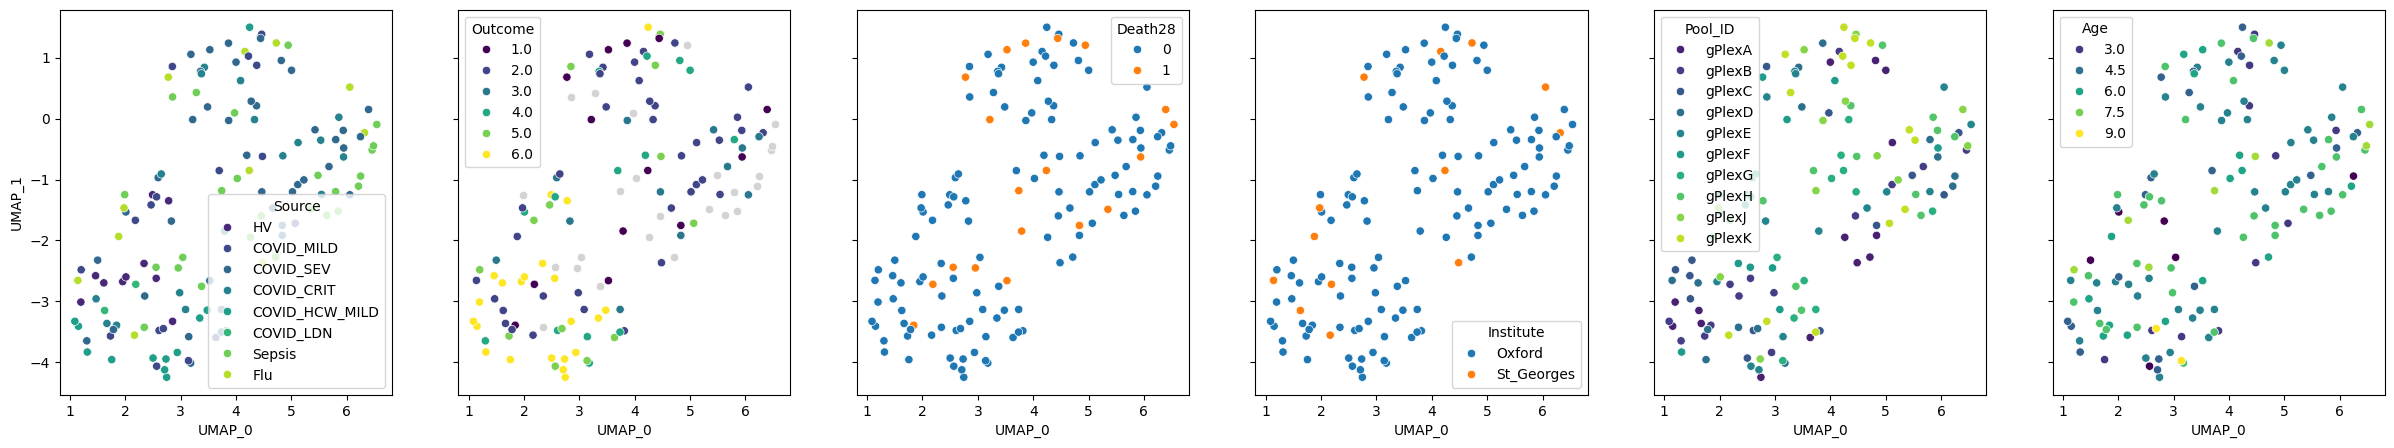

In [20]:
pseudobulk_gene_expression.plot_embedding("UMAP", sample_level_columns)

array([<Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>], dtype=object)

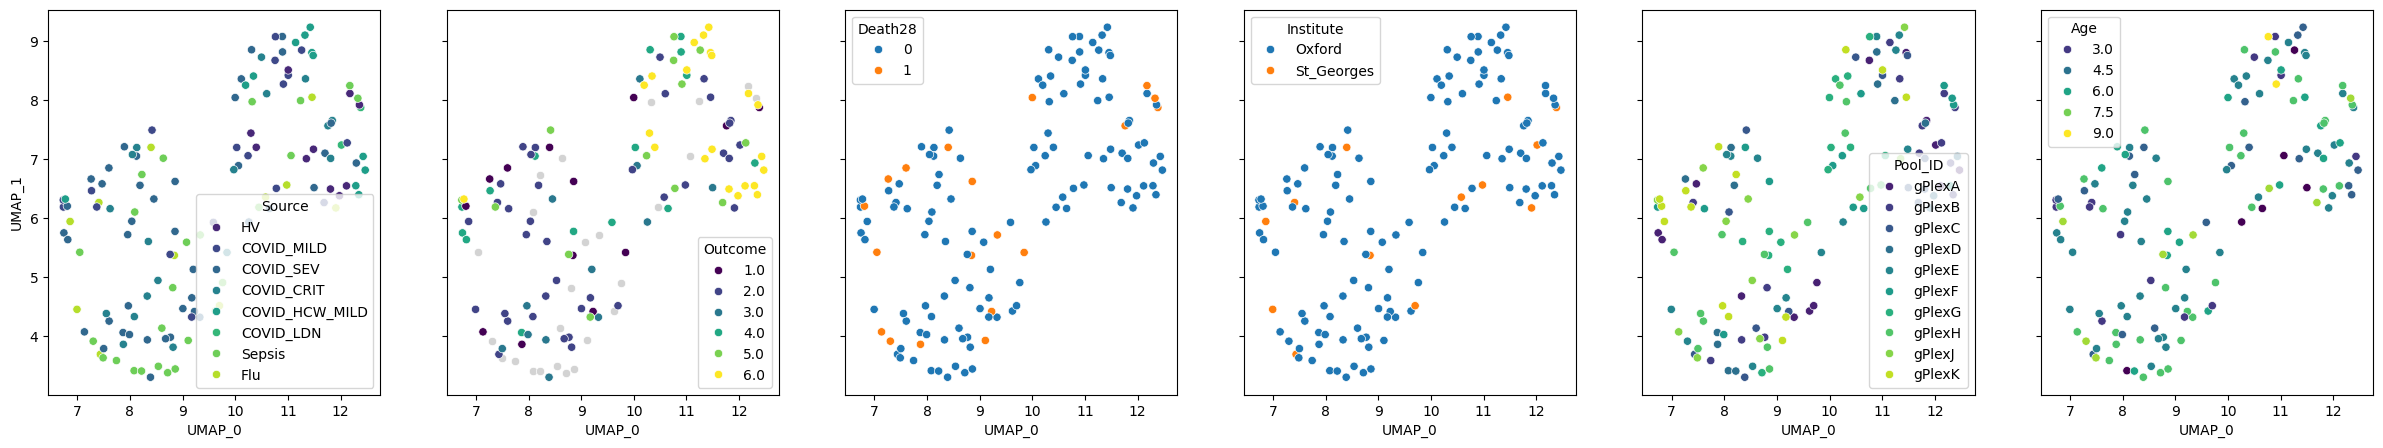

In [21]:
pseudobulk_pca.plot_embedding("UMAP", sample_level_columns)

array([<Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>], dtype=object)

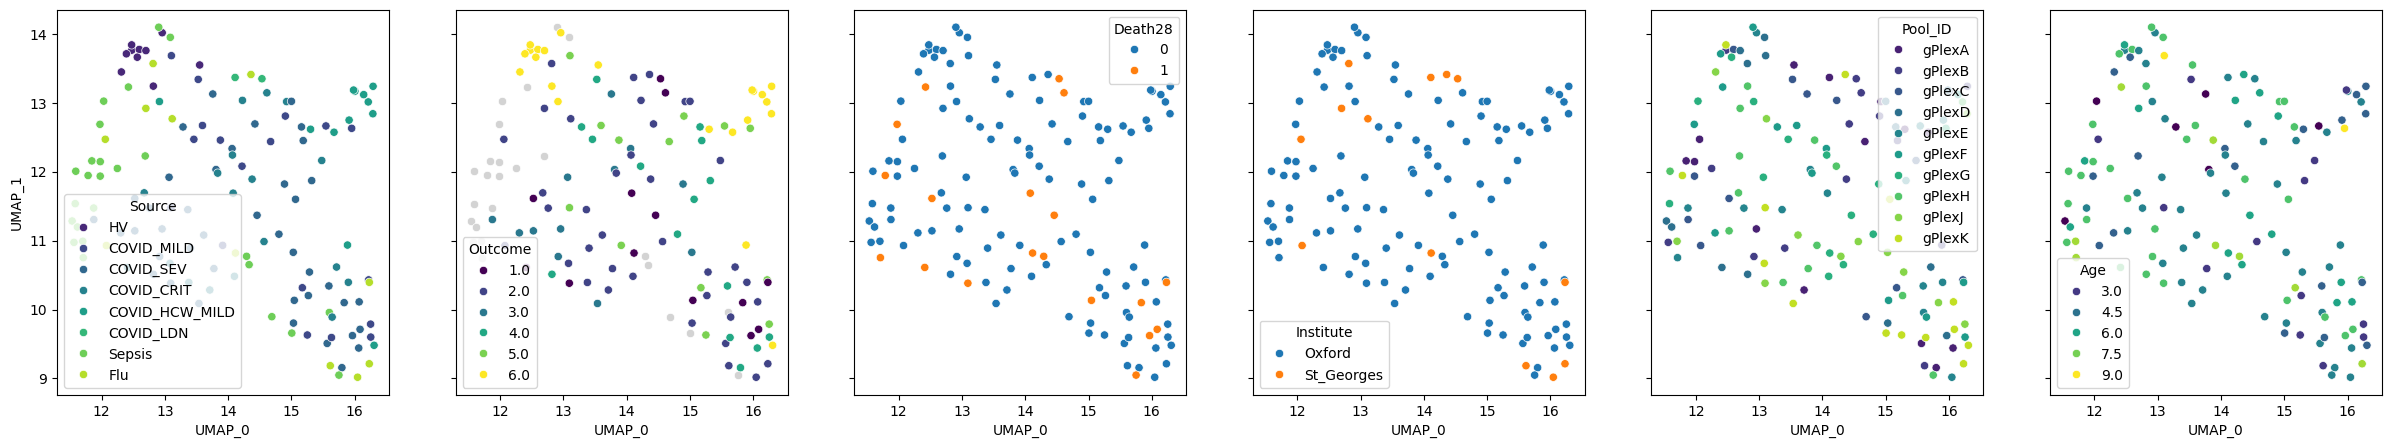

In [22]:
pseudobulk_scvi.plot_embedding("UMAP", sample_level_columns)

### Evaluate how well a covariate is represented

Let's try to classify "Outcome" based on the nearest neighbors for each sample in the representation:

In [23]:
pseudobulk_pca.evaluate_representation(target="Outcome", method="knn", n_neighbors=5, task="classification")

{'score': np.float64(0.1531675764434385),
 'metric': 'f1_macro_calibrated',
 'n_unique': 6,
 'n_observations': 112,
 'method': 'knn'}

It doesn't work too good. Now we can try to solve the ranking problem for the same covariate. It will train regressor and use a different metric for evaluation:

In [24]:
pseudobulk_pca.evaluate_representation(target="Outcome", method="knn", n_neighbors=5, task="ranking")

{'score': np.float64(0.5754976593234707),
 'metric': 'spearman_r',
 'n_unique': 6,
 'n_observations': 112,
 'method': 'knn'}

Now let's see how well Pool is represented. This is a technical covariate so we don't want score to be high:

In [25]:
pseudobulk_pca.evaluate_representation(target="Pool_ID", method="knn", n_neighbors=5, task="classification")

{'score': np.float64(0.14929758350810984),
 'metric': 'f1_macro_calibrated',
 'n_unique': 10,
 'n_observations': 137,
 'method': 'knn'}

Save the distances to adata to use later

In [26]:
adata.uns["pseudobulk_distances"] = pseudobulk_pca.calculate_distance_matrix()
adata.uns["pseudobulk_samples"] = pseudobulk_pca.samples
adata.uns["pseudobulk_UMAP"] = pseudobulk_pca.embeddings["UMAP"]

## Method 2 — CellGroupComposition


This representation is based on cell type composition differences. It is calculated as a difference between cell type proportions in each sample.

In [27]:
import time as _time; _t0 = _time.time()
composition = patpy.tl.CellGroupComposition(
    sample_key=sample_key, cell_group_key=cell_type_key,
)
composition.prepare_anndata(adata)
composition_distances = composition.calculate_distance_matrix(force=True)
runtimes["combat"]["composition"] = _time.time() - _t0


array([<Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>,
       <Axes: xlabel='UMAP_0', ylabel='UMAP_1'>], dtype=object)

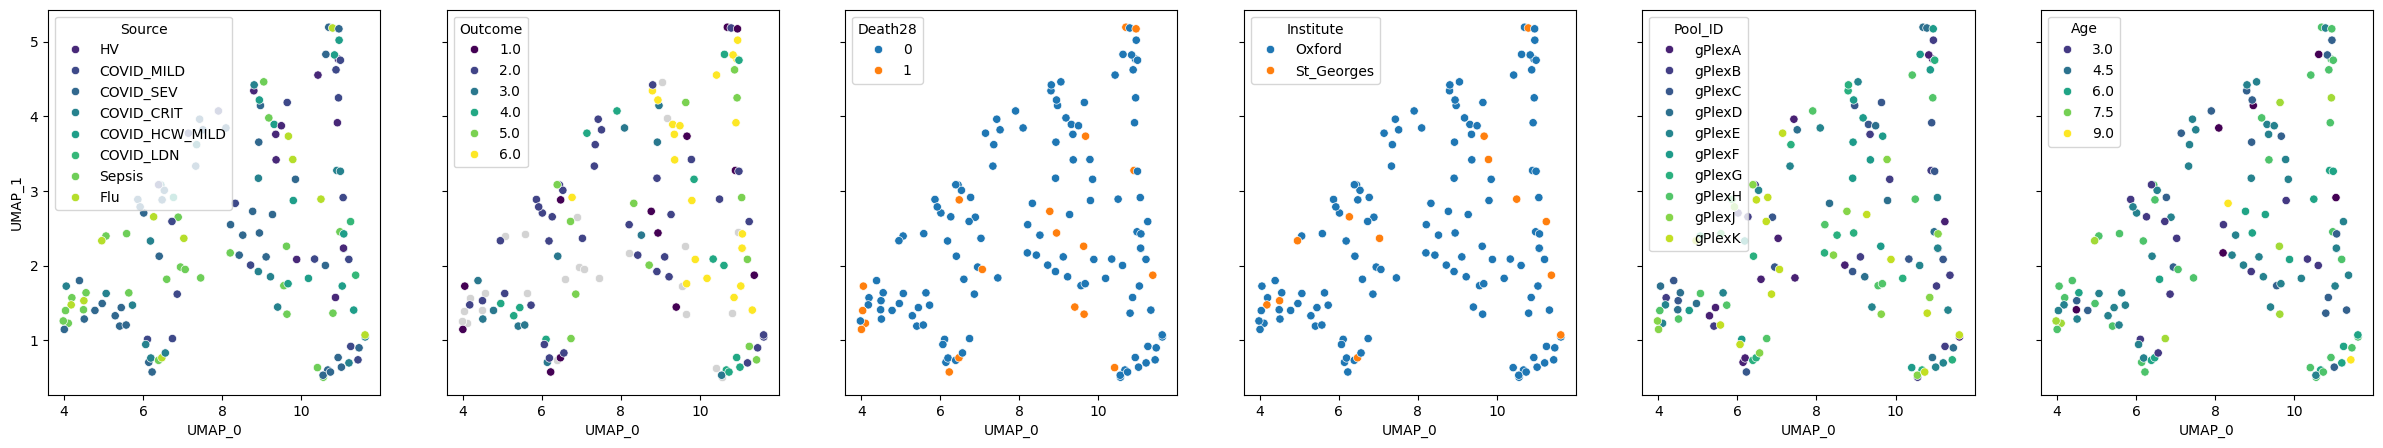

In [28]:
composition.plot_embedding(method="UMAP", metadata_cols=sample_level_columns)

We can also visualise cell type proportions for each sample:

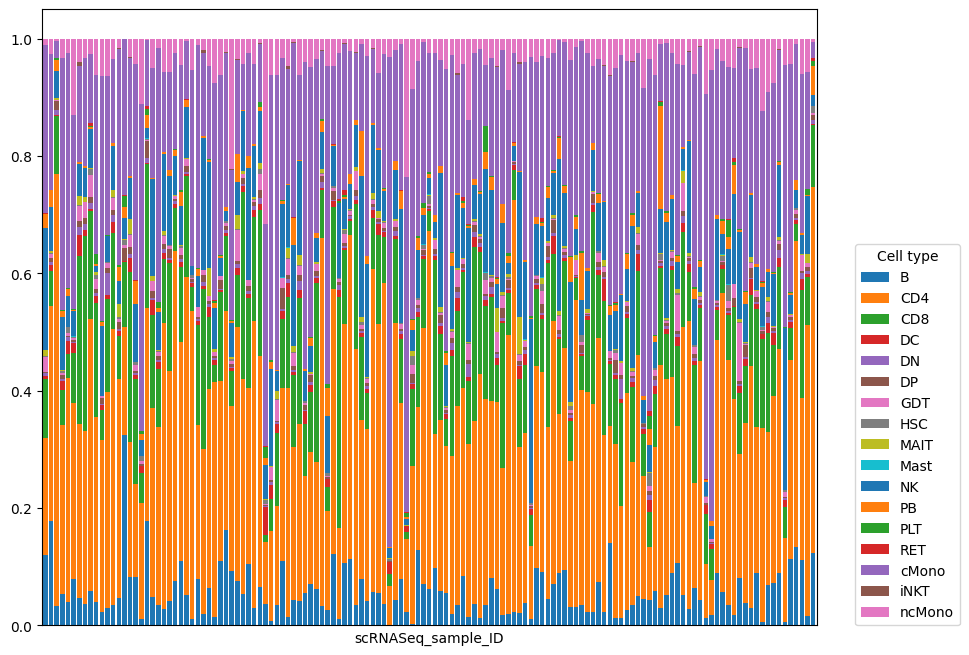

In [29]:
composition.sample_representation.plot(kind="bar", stacked=True, figsize=(10, 8), width=0.8)
plt.xticks([])
plt.legend(loc=(1.05, 0), title="Cell type");

We can see that cell type composition reflects patient outcome worse than pseudobulk:

In [30]:
composition.evaluate_representation(target="Outcome", method="knn", n_neighbors=5, task="ranking")

{'score': np.float64(0.4786968063752981),
 'metric': 'spearman_r',
 'n_unique': 6,
 'n_observations': 112,
 'method': 'knn'}

In [31]:
adata.uns["composition_distances"] = composition_distances
adata.uns["composition_samples"] = composition.samples

## Method 3 — PILOT


[PILOT](https://pubmed.ncbi.nlm.nih.gov/38177382/) is an Optimal Transport-based tool, which calculates distances between samples based on cell type proportion differences taking into account cell type similarities. Note that to run it, you need to install the dependencies additionally:

`pip install patpy[pilot]`

In [32]:
import time as _time; _t0 = _time.time()
pilot = patpy.tl.PILOT(
    sample_key=sample_key,
    cell_group_key=cell_type_key,
    layer="X_scVI_batch",
    sample_state_col="Outcome",  # not used for distance calculation
)
runtimes["combat"]["pilot"] = _time.time() - _t0


In [33]:
pilot.prepare_anndata(adata)

In [34]:
pilot.calculate_distance_matrix()

array([[0.        , 0.14452186, 0.42458347, ..., 0.10953497, 0.21344005,
        0.3680528 ],
       [0.14452186, 0.        , 0.32281266, ..., 0.10045297, 0.13157182,
        0.25767236],
       [0.42458347, 0.32281266, 0.        , ..., 0.36858102, 0.23439425,
        0.08670266],
       ...,
       [0.10953497, 0.10045297, 0.36858102, ..., 0.        , 0.17271712,
        0.311356  ],
       [0.21344005, 0.13157182, 0.23439425, ..., 0.17271712, 0.        ,
        0.21203532],
       [0.3680528 , 0.25767236, 0.08670266, ..., 0.311356  , 0.21203532,
        0.        ]], shape=(137, 137))

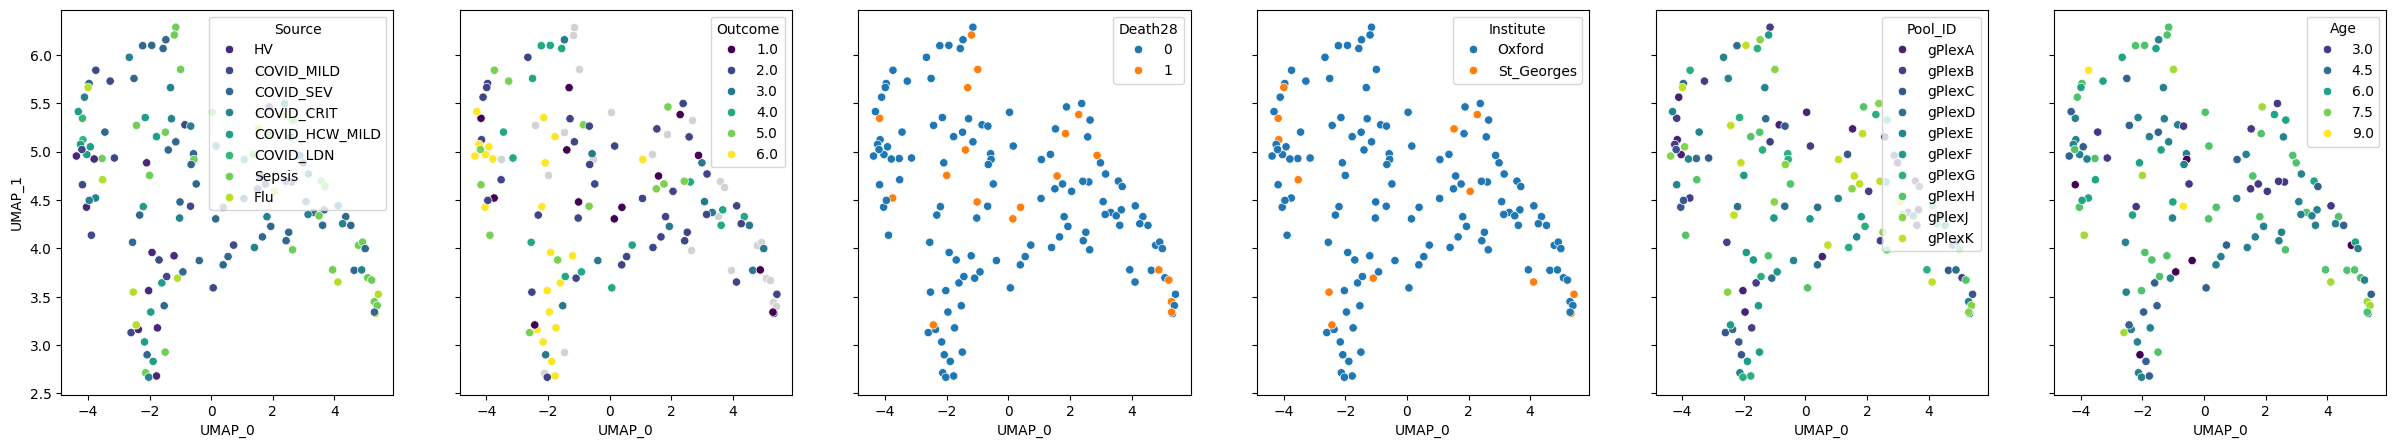

In [35]:
pilot.plot_embedding(method="UMAP", metadata_cols=sample_level_columns);

In [36]:
adata.uns["pilot_distances"] = pilot.calculate_distance_matrix()
adata.uns["pilot_samples"] = pilot.samples
adata.uns["pilot_UMAP"] = pilot.embeddings["UMAP"]

Let's check the covariates:

In [37]:
pilot.evaluate_representation(target="Outcome", method="knn", n_neighbors=5, task="ranking")

{'score': np.float64(0.49516263715930153),
 'metric': 'spearman_r',
 'n_unique': 6,
 'n_observations': 112,
 'method': 'knn'}

In [38]:
pilot.evaluate_representation(target="Pool_ID", method="knn", n_neighbors=5, task="classification")

{'score': np.float64(0.019203256083740555),
 'metric': 'f1_macro_calibrated',
 'n_unique': 10,
 'n_observations': 137,
 'method': 'knn'}

Outcome is represented a bit worse, but Pool ID almost doesn't affect the representation

## Method 4 — GroupedPseudobulk


### Why this method?

GroupedPseudobulk is one step richer than Pseudobulk: instead of one vector per sample, you get one vector *per cell type per sample*, then concatenate them. If your biological signal lives in *which* cell types respond rather than the global average, this representation surfaces it.

Unlike plain Pseudobulk, this method needs at least a few cells in every (sample, cell_type) pair, so we drop very sparse cell types for this method only (via `patpy.pp.filter_small_cell_groups`). All other methods keep the full set of cell types.


In [39]:
import time as _time; _t0 = _time.time()
# GroupedPseudobulk iterates per (sample, cell_type) -- drop sparse cell
# types just for this method so the per-cell-type pseudobulks are well
# defined. The full set of cell types stays available for every other method.
adata_for_grouped = patpy.pp.filter_small_cell_groups(
    adata,
    sample_key=sample_key,
    cell_group_key=cell_type_key,
    cluster_size_threshold=5,
)

grouped_pseudobulk = patpy.tl.GroupedPseudobulk(
    sample_key=sample_key,
    cell_group_key=cell_type_key,
    layer="X_scVI_batch",
)
grouped_pseudobulk.prepare_anndata(adata_for_grouped)
grouped_pseudobulk.calculate_distance_matrix();
runtimes["combat"]["grouped_pseudobulk"] = _time.time() - _t0


13 cell types removed: DP, iNKT, RET, Mast, B, HSC, MAIT, DC, GDT, DN, PLT, ncMono, PB


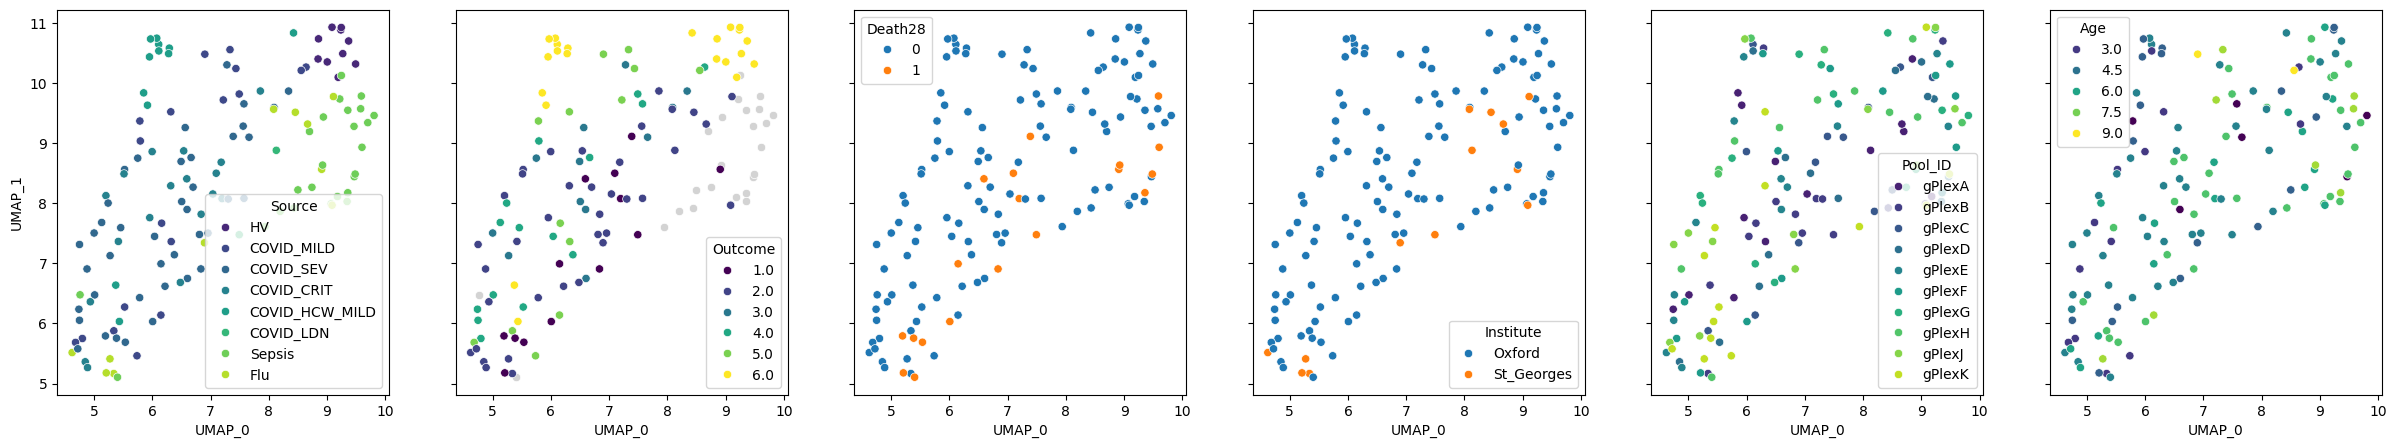

In [40]:
grouped_pseudobulk.plot_embedding(method="UMAP", metadata_cols=sample_level_columns);


In [41]:
adata.uns["grouped_pseudobulk_distances"] = grouped_pseudobulk.calculate_distance_matrix()
adata.uns["grouped_pseudobulk_samples"] = grouped_pseudobulk.samples
adata.uns["grouped_pseudobulk_UMAP"] = grouped_pseudobulk.embeddings["UMAP"]


## Method 5 — RandomVector (sanity baseline)


### Why this method?

RandomVector assigns each sample a vector of Gaussian noise. It exists as a *floor* for the comparison table: any real method should beat random on the clinical covariates and should *not* beat random on the technical ones.


In [42]:
import time as _time; _t0 = _time.time()
random = patpy.tl.RandomVector(
    sample_key=sample_key,
    cell_group_key=cell_type_key,
)
random.prepare_anndata(adata)
random.calculate_distance_matrix();
runtimes["combat"]["random"] = _time.time() - _t0


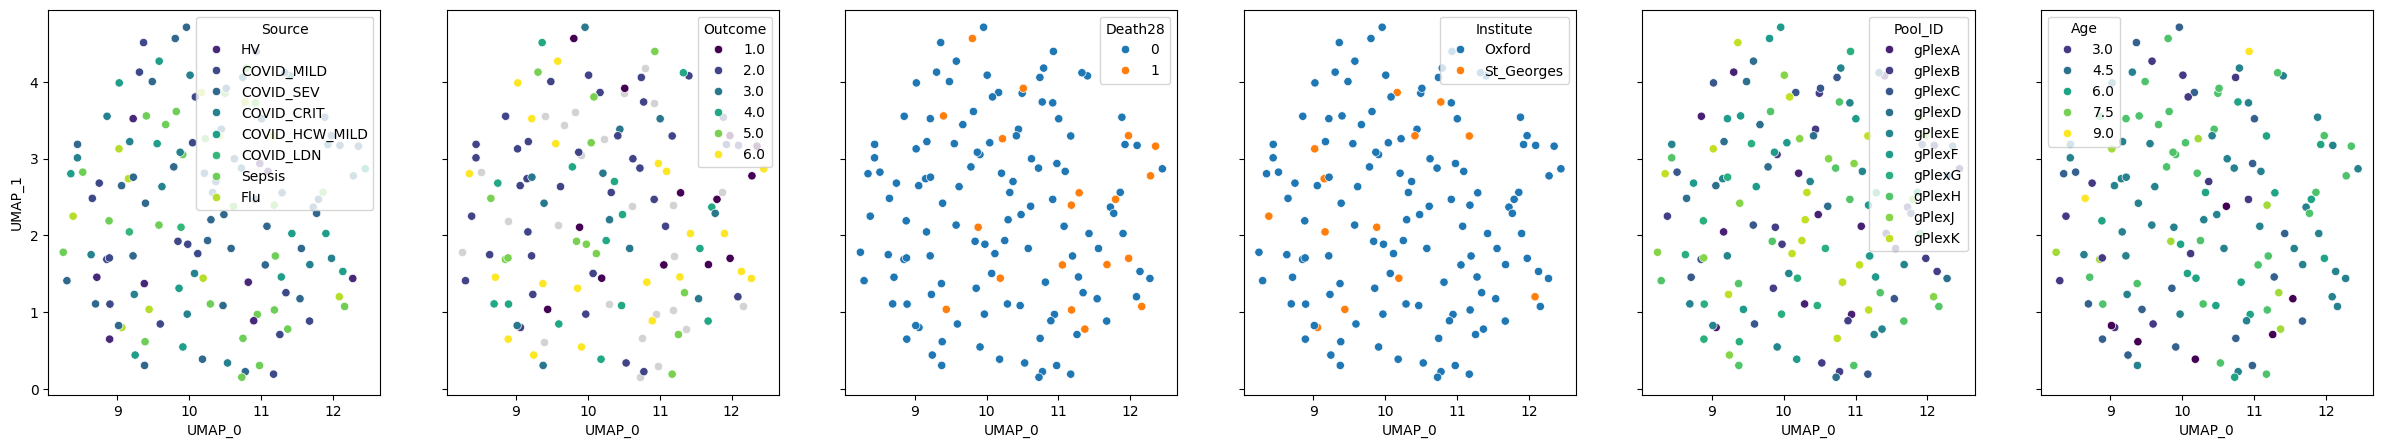

In [43]:
random.plot_embedding(method="UMAP", metadata_cols=sample_level_columns);


In [44]:
adata.uns["random_distances"] = random.calculate_distance_matrix()
adata.uns["random_samples"] = random.samples
adata.uns["random_UMAP"] = random.embeddings["UMAP"]


## Method 6 — MOFA


### Why this method?

MOFA2 fits a multi-view factor model: each cell type becomes a view, and shared latent factors are inferred across views. The factors capture biological axes of variation that are coherent across cell types — useful when no single cell type tells the whole story.

Requires `pip install mofapy2` (no `[mofa]` extra in patpy yet).


In [45]:
import time as _time; _t0 = _time.time()
mofa = patpy.tl.MOFA(
    sample_key=sample_key,
    cell_group_key=cell_type_key,
    n_factors=10,
    aggregate_cell_types=True,
)
mofa.prepare_anndata(adata)
mofa.calculate_distance_matrix();
runtimes["combat"]["mofa"] = _time.time() - _t0



        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         




Features names not provided, using default naming convention:
- feature1_view1, featureD_viewM

Successfully loaded view='NK' group='group1' with N=137 samples and D=3000 features...
Successfully loaded view='CD8' group='group1' with N=137 samples and D=3000 features...
Successfully loaded view='ncMono' group='group1' with N=137 samples and D=3000 features...
Successfully loaded view='cMono' group='group1' with N=137 samples and D=3000 features...
Successfully loaded view='CD4' group='group1' with N=137 samples and D=3000 features...
Successfully loaded view='B' group='group1' with N=137 samples and D=3000 features...
Successfully loaded view='MAIT' group='group1' with N=137 samples and D=3000 features...
Successfully loaded view='PB' group='group1' with N=137 samples and D=3000 features...
Successfully loaded view='iNKT' group='group1' with N=137 samples and D=3000 features...
Successfully loaded view='DN' group='group1' with N=137 samples and D=3000 features...
Successfully loaded vi

Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Likelihoods:
- View 0 (NK): gaussian
- View 1 (CD8): gaussian
- View 2 (ncMono): gaussian
- View 3 (cMono): gaussian
- View 4 (CD4): gaussian
- View 5 (B): gaussian
- View 6 (MAIT): gaussian
- View 7 (PB): gaussian
- View 8 (iNKT): gaussian
- View 9 (DN): gaussian
- View 10 (DP): gaussian
- View 11 (GDT): gaussian
- View 12 (HSC): gaussian
- View 13 (DC): gaussian
- View 14 (PLT): gaussian
- View 15 (RET): gaussian
- View 16 (Mast): gaussian






######################################
## Training the model with seed 67 ##
######################################


ELBO before training: -45716481.44 



Iteration 1: time=0.64, ELBO=11090323.79, deltaELBO=56806805.227 (124.25891809%), Factors=10


...

Iteration 56: time=0.54, ELBO=16438957.21, deltaELBO=874.965 (0.00191389%), Factors=10


Iteration 57: time=0.54, ELBO=16439532.48, deltaELBO=575.268 (0.00125834%), Factors=10


Iteration 58: time=0.54, ELBO=16439933.35, deltaELBO=400.869 (0.00087686%), Factors=10


Iteration 59: time=0.54, ELBO=16440144.05, deltaELBO=210.704 (0.00046089%), Factors=10


Iteration 60: time=0.54, ELBO=16440251.41, deltaELBO=107.354 (0.00023483%), Factors=10

Converged!



#######################
## Training finished ##
#######################




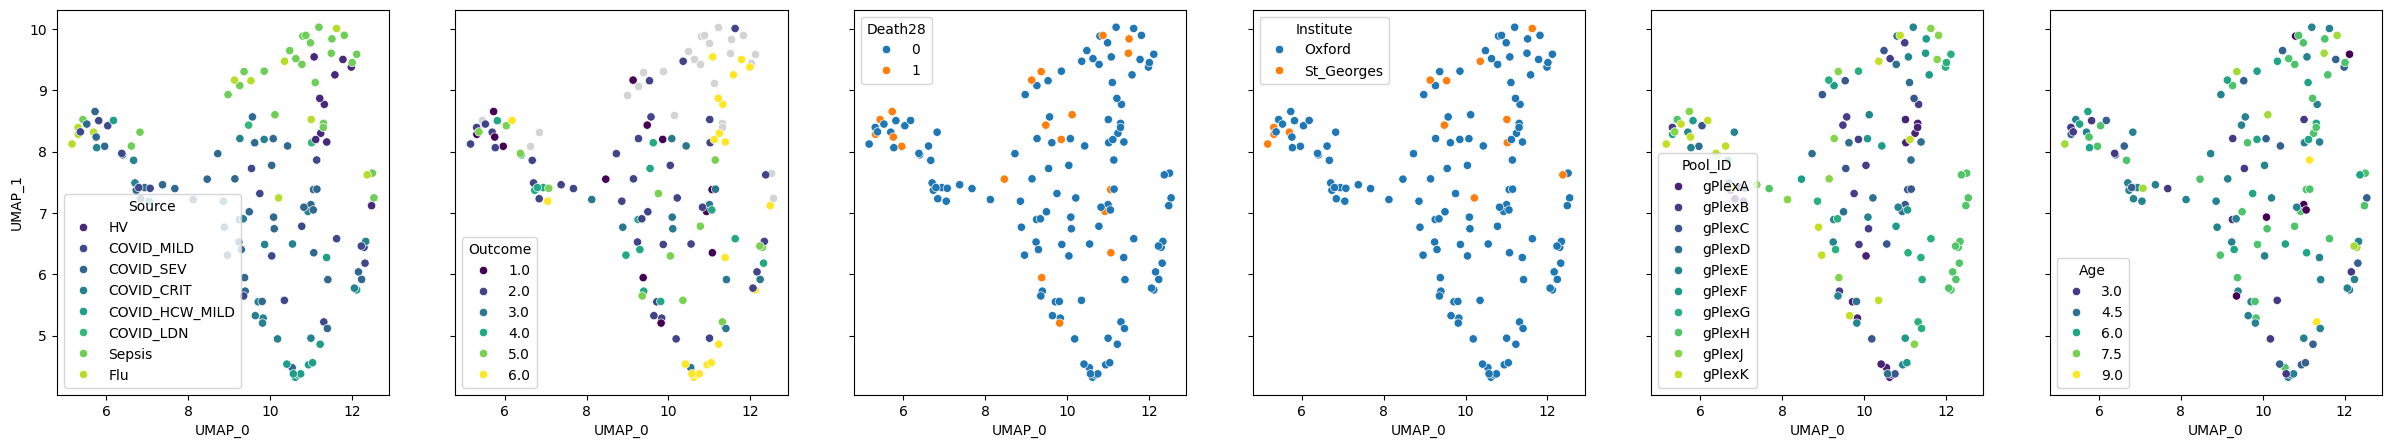

In [46]:
mofa.plot_embedding(method="UMAP", metadata_cols=sample_level_columns);


In [47]:
adata.uns["mofa_distances"] = mofa.calculate_distance_matrix()
adata.uns["mofa_samples"] = mofa.samples
adata.uns["mofa_UMAP"] = mofa.embeddings["UMAP"]


## Method 7 — GloScope (Python)


### Why this method?

GloScope models each sample as a distribution over the cell-state manifold (in some latent embedding) and computes inter-sample distances as a distribution divergence (default: symmetric KL via k-nearest neighbours). Conceptually it sits between PILOT (which compares cell-type proportions weighted by cell similarity) and DiffusionEMD (which moves mass along the diffusion graph): GloScope ignores cell-type labels entirely and just compares the cells' positions in feature space.

We use the pure-Python implementation (`patpy.tl.GloScope_py`); the canonical R version is benchmarked separately in [`sources_of_variation_with_gloscope.ipynb`](./sources_of_variation_with_gloscope.ipynb). Needs `pip install patpy[gloscope-py-cpu]` (or `patpy[gloscope-py-gpu]` for a CUDA speedup).


In [48]:
import time as _time; _t0 = _time.time()
gloscope = patpy.tl.GloScope_py(
    sample_key=sample_key,
    cell_group_key=cell_type_key,
    layer="X_scVI_batch",
    k=25,
    use_gpu=bool(os.environ.get("PATPY_GLOSCOPE_GPU")),
)
gloscope.prepare_anndata(adata)
gloscope.calculate_distance_matrix();
runtimes["combat"]["gloscope"] = _time.time() - _t0


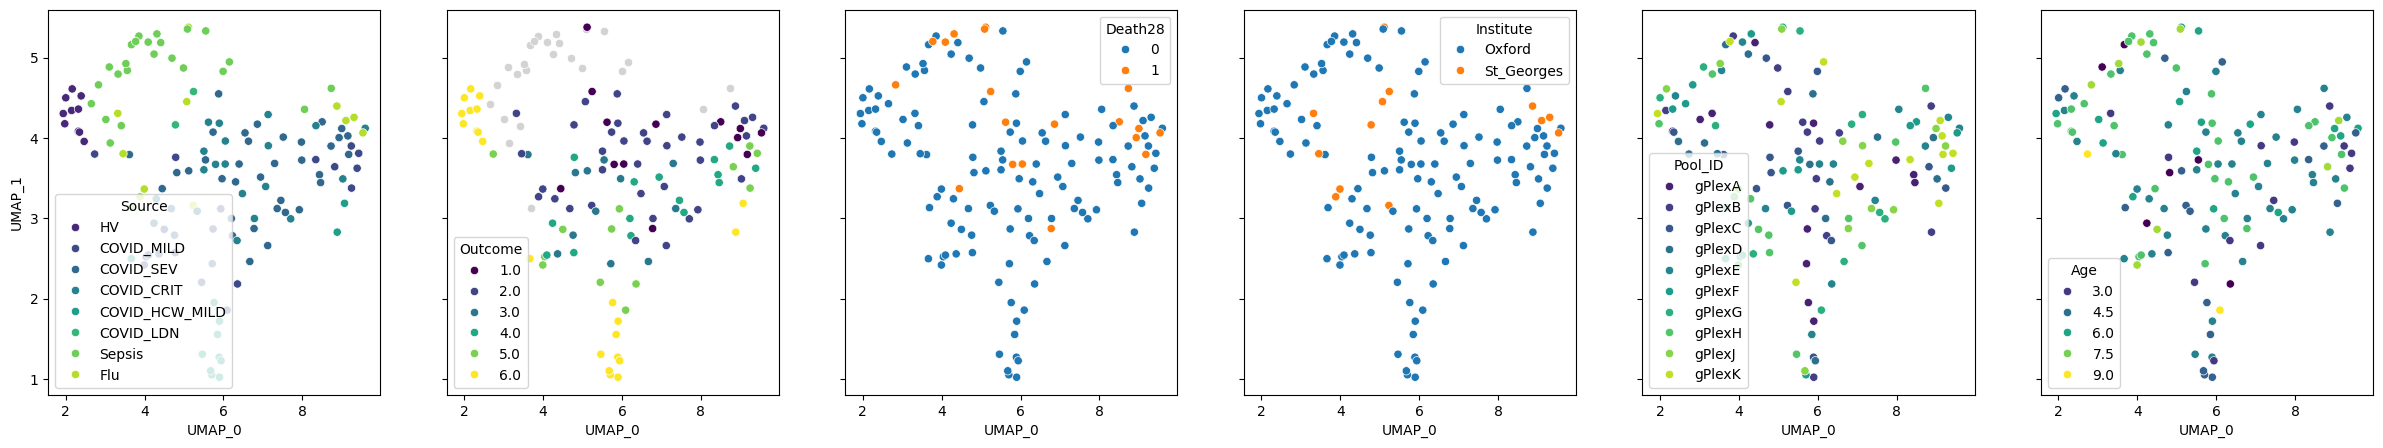

In [49]:
gloscope.plot_embedding(method="UMAP", metadata_cols=sample_level_columns);


In [50]:
adata.uns["gloscope_distances"] = gloscope.calculate_distance_matrix()
adata.uns["gloscope_samples"] = gloscope.samples
adata.uns["gloscope_UMAP"] = gloscope.embeddings["UMAP"]


## Comparing representations

Let's write a small function to put all the sample representations into a single object. It will make sure that the order of samples is identical and cluster the patients

In [51]:
def align_representations(adata, meta_adata, samples, methods):
    """
    Align representations of different methods to have the same order of samples.

    Additionally runs clustering with Leiden algorithm.
    """
    for method in methods:
        #     samples_to_take = np.isin(adata.uns[f"{method}_samples"], samples)
        representation_samples = list(adata.uns[f"{method}_samples"])
        samples_order = [representation_samples.index(sample) for sample in samples if sample in representation_samples]

        assert (np.array(adata.uns[f"{method}_samples"])[samples_order] == samples).all(), "Order of samples is not correct"

        # meta_adata.obsm["umap"] = meta_adata.obsm[f"{method}_UMAP"]
        meta_adata.obsm[f"{method}_distances"] = adata.uns[f"{method}_distances"][samples_order][:, samples_order]

        ep.pp.neighbors(
            meta_adata, use_rep=f"{method}_distances", key_added=f"{method}_neighbors", metric="precomputed"
        )
        ep.tl.leiden(meta_adata, key_added=f"{method}_leiden", neighbors_key=f"{method}_neighbors")

    return meta_adata

In [52]:
combat_methods = [
    "pseudobulk",
    "composition",
    "pilot",
    "grouped_pseudobulk",
    "random",
    "mofa",
    "gloscope",
]


In [53]:
combat_samples = list(set(adata.uns[f"{method}_samples"]) for method in combat_methods)
combat_samples = list(set.intersection(*combat_samples))
len(combat_samples)

137

In [54]:
metadata = metadata.loc[combat_samples]

In [55]:
combat_meta_adata = ep.io.df_to_anndata(metadata)
combat_meta_adata = ep.pp.encode(combat_meta_adata, autodetect=True)
combat_meta_adata

! Features 'Outcome', 'Death28' were detected as categorical features stored numerically.Please verify and correct using `ep.ad.replace_feature_types` if necessary.


! Feature types were inferred and stored in adata.var[feature_type]. Please verify using `ep.ad.feature_type_overview` and adjust if necessary using `ep.ad.replace_feature_types`.


Output()

AnnData object with n_obs × n_vars = 137 × 44
    obs: 'Source', 'Institute', 'Pool_ID'
    var: 'feature_type', 'unencoded_var_names', 'encoding_mode'
    layers: 'original'

In [56]:
combat_meta_adata = align_representations(
    adata=adata,
    meta_adata=combat_meta_adata,
    samples=combat_samples,
    methods=combat_methods,
)

## Evaluation 1 — kNN scores per covariate

For each (representation, covariate) pair, we run a k-nearest-neighbours classification or regression directly on the precomputed sample distances. Scores are normalised to `[0, 1]` and we *invert* the score for technical covariates so that 1 = good (representation ignores the technical artefact) in every column.


In [57]:
benchmark_schema = {
    "technical": ["Institute", "Pool_ID", "n_cells", "median_QC_ngenes"],
    "clinical": ["Death28", "Outcome", "Source"],
}

cols_with_tasks = {
    "Institute": "classification",
    "Pool_ID": "classification",
    "n_cells": "regression",
    "median_QC_ngenes": "regression",
    "Death28": "classification",
    "Outcome": "ranking",
    "Source": "classification",
}

# One colour per method, used in every plot below so the same method has the
# same colour wherever it appears.
method_colors = {
    "pseudobulk": "#1f77b4",
    "composition": "#ff7f0e",
    "pilot": "#2ca02c",
    "grouped_pseudobulk": "#d62728",
    "random": "#7f7f7f",
    "mofa": "#9467bd",
    "gloscope": "#bcbd22",
}


In [58]:
results = []

for method in combat_methods:
    for covariate_type in benchmark_schema:
        for col in benchmark_schema[covariate_type]:
            task = cols_with_tasks[col]
            try:
                result = patpy.tl.evaluate_representation(
                    distances=combat_meta_adata.obsm[f"{method}_distances"],
                    target=metadata[col],
                    method="knn",
                    task=task,
                    #             n_neighbors=5
                )
            except Exception as e:
                print("Method:", method)
                print("Col:", col)
                print("Task:", task)
                print(e)
                print()
                continue
            #             raise(e)
            result["representation"] = method
            result["covariate"] = col
            result["covariate_type"] = covariate_type

            if result["metric"] == "spearman_r":
                result["score"] = abs(result["score"])

            if covariate_type == "technical":
                result["score"] = 1 - result["score"]

            results.append(result)

Scores are ranged from 0 to 1

- For covariates that we defined as technical, 0 means that covariate strongly affects the representation, and 1 means that this covariate is randomly distributed across representation
- For biological and clinical covariates, 0 means that a covariate is not represented well (it is randomly distributed), while 1 means that similar patients have similar values of covariate 

In [59]:
knn_results = pd.DataFrame(results)
knn_results.sort_values("score", ascending=False)

,score,metric,n_unique,n_observations,method,representation,covariate,covariate_type
0,1.000000,f1_macro_calibrated,2,137,knn,pseudobulk,Institute,technical
8,1.000000,f1_macro_calibrated,10,137,knn,composition,Pool_ID,technical
15,1.000000,f1_macro_calibrated,10,137,knn,pilot,Pool_ID,technical
14,1.000000,f1_macro_calibrated,2,137,knn,pilot,Institute,technical
29,1.000000,f1_macro_calibrated,10,137,knn,random,Pool_ID,technical
30,1.000000,spearman_r,137,137,knn,random,n_cells,technical
28,0.951389,f1_macro_calibrated,2,137,knn,random,Institute,technical
21,0.940719,f1_macro_calibrated,2,137,knn,grouped_pseudobulk,Institute,technical
7,0.916860,f1_macro_calibrated,2,137,knn,composition,Institute,technical
1,0.889594,f1_macro_calibrated,10,137,knn,pseudobulk,Pool_ID,technical


Text(0.5, 1.0, 'KNN-score')

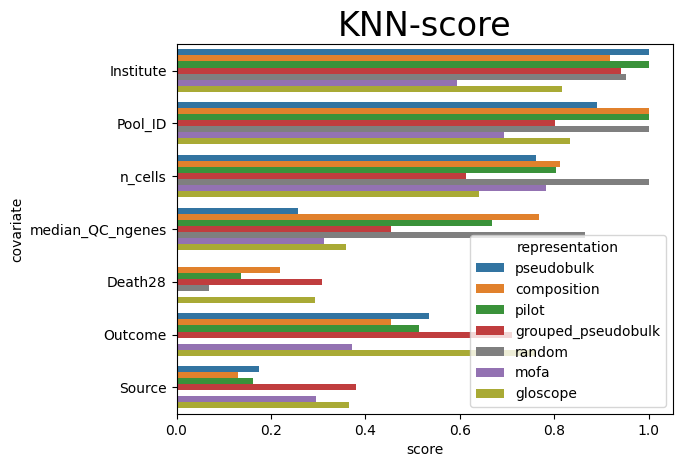

In [60]:
# plt.figure(figsize=(10, 20))
sns.barplot(data=knn_results, y="covariate", x="score", orient="h", hue="representation", palette=method_colors)
plt.xlim(0, 1.05)
plt.title("KNN-score", fontsize=24)

## Evaluation 2 — trajectory preservation

kNN scores are local — they ask whether each sample's neighbours share the same covariate value. They don't tell us whether the *order* of severity is preserved: do healthy donors sit on one side, deceased patients on the other, and milder cases in between?

We answer that with diffusion pseudotime, rooted at a healthy donor: a good representation should produce a pseudotime that correlates with `Outcome` (higher = worse outcome). The Spearman correlation per representation is the score we add to the comparison table.


In [61]:
# Trajectory root: the donor closest to the healthy end of the COMBAT severity scale.
# In COMBAT, Outcome is coded so 6 = healthy / mild HCW and 1 = critical, so we sort
# by Outcome descending. Among the healthiest donors, we break ties on Age (youngest).
# This is robust to test-mode subsampling that may drop all Source=='HV' samples.
candidates = metadata.dropna(subset=["Outcome", "Age"])
root_sample = candidates.sort_values(["Outcome", "Age"], ascending=[False, True]).index[0]
print(
    f"Trajectory root: {root_sample} "
    f"(Outcome={metadata.loc[root_sample, 'Outcome']:.0f}, "
    f"Age={metadata.loc[root_sample, 'Age']:.0f}, "
    f"Source={metadata.loc[root_sample, 'Source']})"
)


Trajectory root: G05078-Ja005E-PBCa (Outcome=6, Age=3, Source=COVID_HCW_MILD)


In [62]:
trajectory_results = patpy.tl.trajectory_correlation(
    meta_adata=combat_meta_adata,
    root_sample=root_sample,
    trajectory_variable="Outcome",
    representations=combat_methods,
    inverse_trajectory=True,  # COMBAT codes 6 = healthy, 1 = critical
)
trajectory_results


Computing diffmap for pseudobulk
Computing diffmap for composition
Computing diffmap for pilot
Computing diffmap for grouped_pseudobulk
Computing diffmap for random
Computing diffmap for mofa
Computing diffmap for gloscope


,correlation
pseudobulk,0.450696
pilot,0.418825
gloscope,0.417711
grouped_pseudobulk,0.364444
composition,0.244055
mofa,0.208236
random,-0.116115


In [63]:
knn_results_wide = knn_results.pivot(index="representation", columns="covariate", values="score")

# Add trajectory preservation score early so it can feed into col_defs below
knn_results_wide["Trajectory"] = (
    trajectory_results.loc[knn_results_wide.index, "correlation"].abs()
)

# Group covariates by the two scoring buckets, with new display names
display_buckets = {
    "Information retention": benchmark_schema["clinical"],
    "Batch mixing": benchmark_schema["technical"],
}

# Per-bucket means -> bucket columns
for bucket, cols in display_buckets.items():
    knn_results_wide[bucket] = knn_results_wide[cols].mean(axis=1)

# New total: (2 * info + 2 * trajectory + batch_mixing) / 5
knn_results_wide["Total"] = (
    2 * knn_results_wide["Information retention"]
    + 2 * knn_results_wide["Trajectory"]
    + knn_results_wide["Batch mixing"]
) / 5

cols_order = ["Total", "Information retention", "Trajectory", "Batch mixing"]
cols_order += display_buckets["Information retention"]
cols_order += display_buckets["Batch mixing"]

cmap_bar = LinearSegmentedColormap.from_list(
    name="bugw", colors=["#FF9693", "#f2fbd2", "#c9ecb4", "#93d3ab", "#35b0ab"], N=256,
)

bar_kw = {
    "cmap": cmap_bar, "plot_bg_bar": True, "annotate": True,
    "height": 0.5, "lw": 0.5, "formatter": lambda x: round(x, 2),
}

col_defs = [
    ColumnDefinition("Total", width=0.7, plot_fn=bar, plot_kw=bar_kw),
    ColumnDefinition(
        "Information retention", width=0.8, plot_fn=bar, plot_kw=bar_kw,
        group="aggregate",
    ),
    ColumnDefinition(
        "Trajectory", width=0.7, plot_fn=bar, plot_kw=bar_kw,
        group="aggregate",
    ),
    ColumnDefinition(
        "Batch mixing", width=0.7, plot_fn=bar, plot_kw=bar_kw,
        group="aggregate",
    ),
]
for col in display_buckets["Information retention"]:
    col_defs.append(ColumnDefinition(
        name=col, width=0.55, formatter=lambda x: round(x, 2),
        textprops={"ha": "center", "bbox": {"boxstyle": "circle", "pad": 0.35}},
        cmap=normed_cmap(knn_results["score"], cmap=matplotlib.cm.PiYG, num_stds=2.5),
        group="Information retention covariates",
    ))
for col in display_buckets["Batch mixing"]:
    col_defs.append(ColumnDefinition(
        name=col, width=0.55, formatter=lambda x: round(x, 2),
        textprops={"ha": "center", "bbox": {"boxstyle": "circle", "pad": 0.35}},
        cmap=normed_cmap(knn_results["score"], cmap=matplotlib.cm.PiYG, num_stds=2.5),
        group="Batch mixing covariates",
    ))


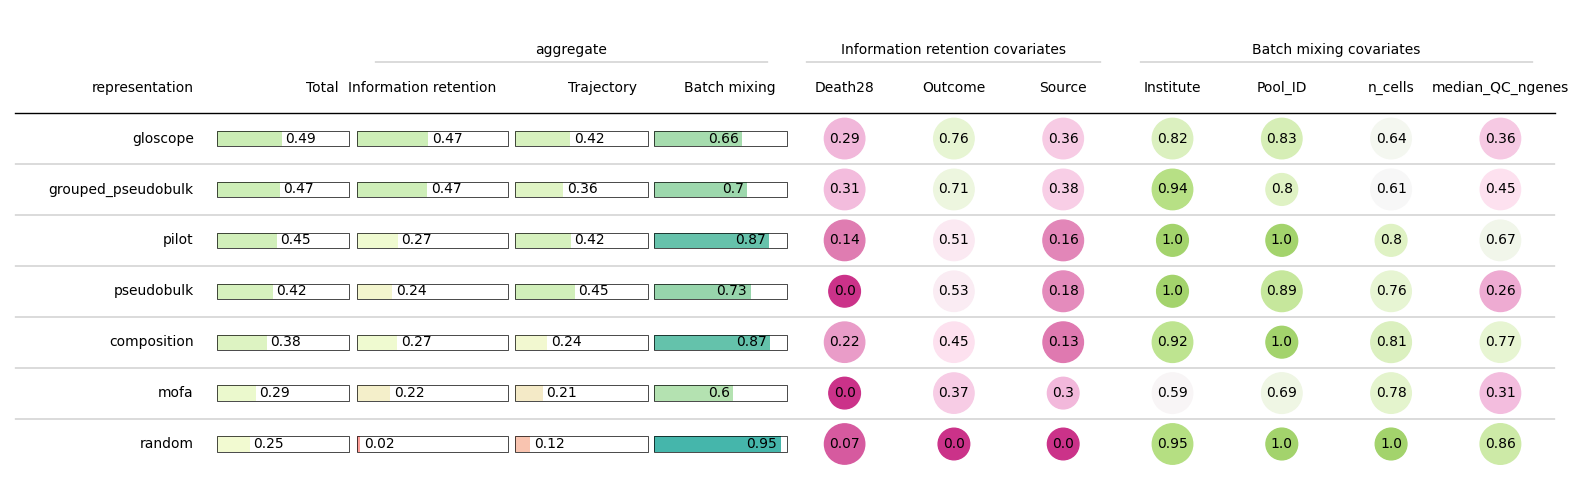

In [64]:
fig, ax = plt.subplots(figsize=(20, 6))
Table(knn_results_wide[cols_order].sort_values("Total", ascending=False), column_definitions=tuple(col_defs), ax=ax)


### How to read this table

Every cell is a score in `[0, 1]` where **higher = better**:

- **Clinical** columns (`Outcome`, `Death28`, `Source`): high means a kNN classifier trained on the sample distances recovers the clinical label.
- **Technical** columns (`Institute`, `Pool_ID`, `n_cells`, `median_QC_ngenes`): high means the *opposite* — the score has been inverted so that high indicates the representation does **not** encode the technical artefact.
- **`trajectory`** is the absolute Spearman correlation between diffusion pseudotime (rooted at the healthiest donor) and `Outcome`. High means the order of severity is preserved along the representation's diffusion graph.
- **`total`** is a weighted average that gives more weight to clinical signal than to batch invariance, so the top of the sorted table is the method most useful for downstream clinical analysis on this dataset.

The `random` baseline is the floor: any real method should beat it on clinical and trajectory columns. If a method *doesn't* beat random there, the method or its hyperparameters need work for this dataset.


## A reusable benchmark helper

To compare against other datasets we need to repeat the same workflow: run every method, score each one against a "relevant" (clinical) covariate set and a "technical" covariate set, and compute a trajectory correlation. Below is a single helper that does all of that, returning per-method distances, kNN scores, and a summary table. We'll call it three times: once each for COMBAT (already done above), HLCA, and Stephenson.


In [65]:
import time
import gc

def run_all_methods_on_dataset(
    adata,
    *,
    sample_key,
    cell_type_key,
    layer="X_scVI_batch",
    cluster_size_threshold=5,
):
    """Run all seven representation methods on `adata`.

    Returns
    -------
    dict with keys 'distances', 'samples', 'runtimes' (each keyed by method name).
    """
    out = {"distances": {}, "samples": {}, "runtimes": {}}

    method_specs = [
        ("pseudobulk", lambda: patpy.tl.Pseudobulk(
            sample_key=sample_key, cell_group_key=cell_type_key, layer=layer)),
        ("composition", lambda: patpy.tl.CellGroupComposition(
            sample_key=sample_key, cell_group_key=cell_type_key)),
        ("pilot", lambda: patpy.tl.PILOT(
            sample_key=sample_key, cell_group_key=cell_type_key, layer=layer)),
        ("random", lambda: patpy.tl.RandomVector(
            sample_key=sample_key, cell_group_key=cell_type_key)),
        ("mofa", lambda: patpy.tl.MOFA(
            sample_key=sample_key, cell_group_key=cell_type_key,
            n_factors=10, aggregate_cell_types=True)),
        ("gloscope", lambda: patpy.tl.GloScope_py(
            sample_key=sample_key, cell_group_key=cell_type_key, layer=layer, k=25,
            use_gpu=bool(os.environ.get("PATPY_GLOSCOPE_GPU")))),
    ]
    for name, factory in method_specs:
        try:
            t0 = time.time()
            m = factory()
            m.prepare_anndata(adata)
            out["distances"][name] = m.calculate_distance_matrix(force=True)
            out["samples"][name] = list(m.samples)
            out["runtimes"][name] = time.time() - t0
            print(f"  {name}: {out['runtimes'][name]:.1f}s")
        except Exception as e:
            print(f"  {name} FAILED: {type(e).__name__}: {e}")

    # GroupedPseudobulk needs a denser per-(sample, cell_type) matrix --
    # filter sparse cell types just for this method.
    try:
        adata_filtered = patpy.pp.filter_small_cell_groups(
            adata, sample_key=sample_key, cell_group_key=cell_type_key,
            cluster_size_threshold=cluster_size_threshold,
        )
        t0 = time.time()
        m = patpy.tl.GroupedPseudobulk(
            sample_key=sample_key, cell_group_key=cell_type_key, layer=layer)
        m.prepare_anndata(adata_filtered)
        out["distances"]["grouped_pseudobulk"] = m.calculate_distance_matrix()
        out["samples"]["grouped_pseudobulk"] = list(m.samples)
        out["runtimes"]["grouped_pseudobulk"] = time.time() - t0
        print(f"  grouped_pseudobulk: {out['runtimes']['grouped_pseudobulk']:.1f}s")
        del adata_filtered
        gc.collect()
    except Exception as e:
        print(f"  grouped_pseudobulk FAILED: {type(e).__name__}: {e}")

    return out


def score_methods_on_dataset(
    bench_result,
    *,
    metadata,
    sample_key,
    schema,
    root_sample,
    trajectory_variable,
    inverse_trajectory=False,
    n_neighbors=5,
):
    """Score the methods produced by `run_all_methods_on_dataset` against
    a SPARE-style `schema` (dict with at least 'relevant' / 'technical' keys
    mapping to {covariate: task}). Computes a trajectory_correlation if the
    `trajectory_variable` and `root_sample` are present in `metadata`.

    Returns
    -------
    dict with keys 'long' (long-format scores), 'summary' (per-method
    Information retention / Batch mixing / Trajectory / Total / Runtime),
    and 'meta_adata' (the encoded ehrapy AnnData used for diffmap).
    """
    methods_all = list(bench_result["distances"].keys())
    # Drop methods that ended up with zero samples (otherwise the
    # intersection across methods is empty and nothing gets scored).
    methods = [m for m in methods_all if len(bench_result["samples"][m]) > 0]
    if len(methods) < len(methods_all):
        empty = [m for m in methods_all if m not in methods]
        print(f"  dropping methods with 0 samples: {empty}")
    # Common samples across the surviving methods
    method_sample_sets = {m: set(bench_result["samples"][m]) for m in methods}
    common = set.intersection(*method_sample_sets.values()) if method_sample_sets else set()
    common = [s for s in metadata.index if s in common]
    print(f"  scoring on {len(common)} samples (methods: {[(m, len(s)) for m, s in method_sample_sets.items()]})")
    if len(common) < 4:
        print("  too few common samples for kNN scoring; returning empty summary")
        empty = pd.Series(np.nan, index=methods)
        summary = pd.DataFrame({
            "Information retention": empty,
            "Batch mixing": empty,
            "Trajectory": empty,
            "Runtime (s)": pd.Series(bench_result["runtimes"]).reindex(methods),
            "Total": empty,
        })
        return {"long": pd.DataFrame(), "summary": summary, "meta_adata": None}
    meta = metadata.loc[common].copy()
    # Drop all-NaN columns -- ehrapy.encode chokes on them
    meta = meta.dropna(axis=1, how="all")
    meta_adata = ep.io.df_to_anndata(meta)
    meta_adata = ep.pp.encode(meta_adata, autodetect=True)

    for m in methods:
        order = [bench_result["samples"][m].index(s) for s in common]
        d = bench_result["distances"][m]
        meta_adata.obsm[f"{m}_distances"] = d[np.ix_(order, order)]
        _n_nbrs = min(15, max(2, len(common) - 1))
        ep.pp.neighbors(
            meta_adata, use_rep=f"{m}_distances",
            key_added=f"{m}_neighbors", metric="precomputed",
            n_neighbors=_n_nbrs,
        )

    # kNN scoring
    long_rows = []
    for group, cov_tasks in schema.items():
        for col, task in cov_tasks.items():
            if col not in meta.columns:
                continue
            for m in methods:
                try:
                    r = patpy.tl.evaluate_representation(
                        distances=meta_adata.obsm[f"{m}_distances"],
                        target=meta[col],
                        method="knn", task=task, n_neighbors=n_neighbors,
                    )
                except Exception as e:
                    print(f"  skipped {m}/{col}: {e}")
                    continue
                score = r["score"]
                if r.get("metric") == "spearman_r":
                    score = abs(score)
                if group == "technical":
                    score = 1 - score
                long_rows.append({
                    "representation": m, "covariate": col,
                    "covariate_type": group, "score": score,
                })
    long_df = pd.DataFrame(long_rows)

    # Trajectory correlation
    traj_series = pd.Series(np.nan, index=methods)
    if (
        trajectory_variable in meta.columns
        and root_sample in meta.index
    ):
        # If trajectory_variable is categorical text, encode to ordered numeric
        traj_target = meta[trajectory_variable]
        if traj_target.dtype.name == "category" or traj_target.dtype == object:
            traj_target_num = traj_target.astype("category").cat.codes.astype(float)
            traj_target_num[traj_target.isna()] = np.nan
            meta_adata.obs[trajectory_variable] = traj_target_num.values
        try:
            traj_df = patpy.tl.trajectory_correlation(
                meta_adata=meta_adata, root_sample=root_sample,
                trajectory_variable=trajectory_variable, representations=methods,
                inverse_trajectory=inverse_trajectory,
            )
            traj_series = traj_df["correlation"].abs()
        except Exception as e:
            print(f"  trajectory_correlation failed: {e}")
    else:
        print(
            f"  trajectory skipped: variable={trajectory_variable!r} in metadata? "
            f"{trajectory_variable in meta.columns}; root={root_sample!r} in samples? "
            f"{root_sample in meta.index}"
        )

    # Per-method summary
    methods_idx = pd.Index(methods, name="representation")
    info = pd.Series({
        m: long_df[
            (long_df["representation"] == m)
            & (long_df["covariate_type"].isin(["relevant", "clinical"]))
        ]["score"].mean()
        for m in methods
    })
    batch = pd.Series({
        m: long_df[
            (long_df["representation"] == m)
            & (long_df["covariate_type"] == "technical")
        ]["score"].mean()
        for m in methods
    })
    traj = traj_series.reindex(methods_idx)
    runtimes_s = pd.Series(bench_result["runtimes"]).reindex(methods_idx)

    summary = pd.DataFrame({
        "Information retention": info,
        "Batch mixing": batch,
        "Trajectory": traj,
        "Runtime (s)": runtimes_s,
    })
    # New total: (2*info + 2*traj + batch) / 5; NaN trajectory falls back to 0 weight
    traj_filled = summary["Trajectory"].fillna(0)
    summary["Total"] = (
        2 * summary["Information retention"].fillna(0)
        + 2 * traj_filled
        + summary["Batch mixing"].fillna(0)
    ) / 5
    summary = summary.sort_values("Total", ascending=False)

    return {"long": long_df, "summary": summary, "meta_adata": meta_adata}


### COMBAT summary for the cross-dataset view


In [66]:
# Pre-compute a COMBAT summary in the same shape we'll build for HLCA + Stephenson
combat_summary = pd.DataFrame({
    "Information retention": knn_results_wide["Information retention"],
    "Batch mixing": knn_results_wide["Batch mixing"],
    "Trajectory": knn_results_wide["Trajectory"],
    "Runtime (s)": pd.Series(runtimes["combat"]).reindex(knn_results_wide.index),
})
combat_summary["Total"] = knn_results_wide["Total"]
combat_summary = combat_summary.sort_values("Total", ascending=False)
dataset_summaries["combat"] = combat_summary
combat_summary.round(2)


,Information retention,Batch mixing,Trajectory,Runtime (s),Total
representation,,,,,
gloscope,0.47,0.66,0.42,77.14,0.49
grouped_pseudobulk,0.47,0.70,0.36,44.71,0.47
pilot,0.27,0.87,0.42,0.00,0.45
pseudobulk,0.24,0.73,0.45,0.22,0.42
composition,0.27,0.87,0.24,0.21,0.38
mofa,0.22,0.60,0.21,38.00,0.29
random,0.02,0.95,0.12,0.01,0.25


In [67]:
# COMBAT analysis done; release the AnnData (and any heavy intermediates) so
# HLCA + Stephenson have memory headroom.
del adata, combat_meta_adata, knn_results, knn_results_wide
gc.collect()


89208

## Benchmark on HLCA


On to the Human Lung Cell Atlas (HLCA) {cite}`sikkema2023integrated`: ~340 donors across health and lung disease, multiple sequencing platforms. We subsample to 50 donors x 20% cells so each method finishes in a few minutes, then run the same seven methods with the SPARE benchmark schema (clinical / technical / trajectory). The summary table at the end is structurally identical to COMBAT's, just on a different cohort and different question.


In [68]:
hlca, hlca_info = patpy.datasets.hlca(return_dataset_info=True)
print(f"HLCA loaded: {hlca.n_obs} cells, {hlca.obs[hlca_info.sample_key].nunique()} donors")


HLCA loaded: 1687127 cells, 339 donors


In [69]:
# In test mode keep this small to iterate fast. Otherwise use the full HLCA --
# all 339 donors, 1.7M cells (no subsampling).
if os.environ.get('PATPY_NB_TEST'):
    rng = np.random.default_rng(67)
    _donors = rng.choice(
        hlca.obs[hlca_info.sample_key].unique(),
        size=min(20, hlca.obs[hlca_info.sample_key].nunique()),
        replace=False,
    )
    hlca = hlca[hlca.obs[hlca_info.sample_key].isin(_donors)].copy()
    hlca = patpy.pp.subsample(
        hlca,
        obs_category_col=hlca_info.sample_key,
        min_samples_per_category=200,
        fraction=0.1,
    )
hlca = patpy.pp.filter_small_samples(hlca, sample_key=hlca_info.sample_key, sample_size_threshold=200)
print(f'HLCA after QC: {hlca.n_obs} cells, {hlca.obs[hlca_info.sample_key].nunique()} donors')


3 samples removed: homosapiens_None_2023_None_sikkemalisa_002_d10_1101_2022_03_10_483747244C, homosapiens_None_2023_None_sikkemalisa_002_d10_1101_2022_03_10_483747NP11, homosapiens_None_2023_None_sikkemalisa_002_d10_1101_2022_03_10_483747VUHD105


HLCA after QC: 1686679 cells, 336 donors


In [70]:
# Extract sample-level metadata for the SPARE-style scoring (clinical = "relevant",
# technical = batch / acquisition artefacts). Skip "contextual" columns -- we don't
# score them, they're neither clinical signal nor technical noise.
hlca_sample_cols = [
    "tissue", "anatomical_region_ccf_score", "lung_condition", "disease",
    "smoking_status", "suspension_type", "core_or_extension", "fresh_or_frozen",
    "sequencing_platform", "subject_type", "assay", "development_stage",
    "BMI", "age_or_mean_of_age_range", "sex",
]
# Only ask for columns that exist
hlca_sample_cols = [c for c in hlca_sample_cols if c in hlca.obs.columns]
hlca_meta = patpy.pp.extract_metadata(hlca, hlca_info.sample_key, hlca_sample_cols)
hlca_qc = patpy.pp.calculate_cell_qc_metrics(
    hlca, sample_key=hlca_info.sample_key,
    cell_qc_vars=[c for c in ["n_genes_by_counts", "total_counts", "pct_counts_mt"] if c in hlca.obs.columns],
)
hlca_ncells = patpy.pp.calculate_n_cells_per_sample(hlca, hlca_info.sample_key)
hlca_meta = pd.concat([hlca_meta, hlca_qc.loc[hlca_meta.index], hlca_ncells.loc[hlca_meta.index]], axis=1)
hlca_meta.head()


,tissue,anatomical_region_ccf_score,lung_condition,disease,smoking_status,suspension_type,core_or_extension,fresh_or_frozen,sequencing_platform,subject_type,assay,development_stage,BMI,age_or_mean_of_age_range,sex,median_n_genes_by_counts,median_total_counts,median_pct_counts_mt,n_cells
donor_id,,,,,,,,,,,,,,,,,,,
homosapiens_None_2023_None_sikkemalisa_002_d10_1101_2022_03_10_483747Donor_02,lung parenchyma,0.97,Healthy,normal,former,cell,core,fresh,Illumina HiSeq 4000,organ_donor,10x 3' v2,55-year-old stage,NaN,55.0,male,204.0,330.554077,0.0,3832
homosapiens_None_2023_None_sikkemalisa_002_d10_1101_2022_03_10_483747cc05p,lung,NaN,Healthy,normal,NaN,cell,extension,NaN,NaN,NaN,10x 3' v2,unknown,NaN,NaN,unknown,145.0,301.329895,0.0,1687
homosapiens_None_2023_None_sikkemalisa_002_d10_1101_2022_03_10_483747VUHD68,lung parenchyma,0.97,Healthy,normal,former,cell,core,fresh,Illumina NovaSeq 6000 S1,organ_donor,10x 5' v1,41-year-old stage,23.5,41.0,male,183.0,344.931091,0.0,7850
homosapiens_None_2023_None_sikkemalisa_002_d10_1101_2022_03_10_483747D062,lung,NaN,Healthy,normal,NaN,nucleus,extension,NaN,NaN,NaN,10x 3' v3,newborn stage (0-28 days),NaN,0.0,male,135.0,231.189117,0.0,4852
homosapiens_None_2023_None_sikkemalisa_002_d10_1101_2022_03_10_483747donor 1,lung parenchyma,0.97,Healthy (tumor adjacent),normal,former,cell,core,fresh,Illumina NovaSeq 6000,alive_disease,10x 3' v2,75-year-old stage,24.6,75.0,male,197.0,338.632477,0.0,7523


In [71]:
print("Running 7 methods on HLCA:")
hlca_bench = run_all_methods_on_dataset(
    hlca,
    sample_key=hlca_info.sample_key,
    cell_type_key=hlca_info.cell_type_key,
    layer="X_scVI_batch",
)
runtimes["hlca"] = hlca_bench["runtimes"]


Running 7 methods on HLCA:


  pseudobulk: 0.9s


  composition: 0.8s


  pilot FAILED: KeyError: '[None] not in index'
  random: 0.0s



        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         




...

Iteration 95: time=7.02, ELBO=50897382.43, deltaELBO=866.758 (0.00049693%), Factors=10

Converged!





#######################
## Training finished ##
#######################




  mofa: 578.2s


  gloscope: 205.7s


51 cell types removed: smooth muscle cell, serous secreting cell, CD8-positive, alpha-beta T cell, hematopoietic stem cell, acinar cell, ionocyte, alveolar type 1 fibroblast cell, T cell, alveolar adventitial fibroblast, pulmonary artery endothelial cell, tracheobronchial serous cell, endothelial cell of lymphatic vessel, plasmacytoid dendritic cell, fibroblast, stromal cell, CD1c-positive myeloid dendritic cell, respiratory hillock cell, alveolar macrophage, conventional dendritic cell, nasal mucosa goblet cell, brush cell of tracheobronchial tree, vein endothelial cell, CD4-positive, alpha-beta T cell, elicited macrophage, pulmonary alveolar type 1 cell, dendritic cell, epithelial cell of alveolus of lung, plasma cell, bronchus fibroblast of lung, epithelial cell of lower respiratory tract, club cell, capillary endothelial cell, unknown, myofibroblast cell, tracheobronchial goblet cell, multi-ciliated epithelial cell, bronchial goblet cell, lung neuroendocrine cell, lung pericyte, re

In [72]:
# SPARE schema for HLCA (https://github.com/lueckenlab/SPARE/blob/main/data/hlca/benchmark_schema.json)
hlca_schema = {
    "relevant": {
        "tissue": "classification",
        "anatomical_region_ccf_score": "regression",
        "lung_condition": "classification",
        "disease": "classification",
        "smoking_status": "classification",
    },
    "technical": {
        "suspension_type": "classification",
        "core_or_extension": "classification",
        "fresh_or_frozen": "classification",
        "sequencing_platform": "classification",
        "subject_type": "classification",
        "assay": "classification",
        "median_n_genes_by_counts": "regression",
        "median_total_counts": "regression",
        "median_pct_counts_mt": "regression",
        "n_cells": "regression",
        "development_stage": "classification",
    },
}

hlca_scored = score_methods_on_dataset(
    hlca_bench,
    metadata=hlca_meta,
    sample_key=hlca_info.sample_key,
    schema=hlca_schema,
    root_sample="homosapiens_None_2023_None_sikkemalisa_002_d10_1101_2022_03_10_483747D322",
    trajectory_variable="anatomical_region_ccf_score",
    inverse_trajectory=False,
)
dataset_summaries["hlca"] = hlca_scored["summary"]
hlca_scored["summary"].round(2)


  scoring on 0 samples (methods: [('pseudobulk', 336), ('composition', 336), ('random', 336), ('mofa', 336), ('gloscope', 336), ('grouped_pseudobulk', 0)])
  too few common samples for kNN scoring; returning empty summary


,Information retention,Batch mixing,Trajectory,Runtime (s),Total
pseudobulk,NaN,NaN,NaN,0.90,NaN
composition,NaN,NaN,NaN,0.83,NaN
random,NaN,NaN,NaN,0.01,NaN
mofa,NaN,NaN,NaN,578.21,NaN
gloscope,NaN,NaN,NaN,205.72,NaN
grouped_pseudobulk,NaN,NaN,NaN,0.00,NaN


In [73]:
# Free HLCA to keep peak memory low before Stephenson loads
del hlca, hlca_bench, hlca_scored
gc.collect()


0

## Benchmark on Stephenson


A third cohort to show the workflow generalises beyond two datasets. Stephenson et al. {cite}`stephenson2021single` is another COVID-19 PBMC study, with 131 donors collected across three UK sites -- so a different clinical schema (`Worst_Clinical_Status`, `Status_on_day_collection_summary`) and a different technical artefact (`Site`).


In [74]:
stephenson, stephenson_info = patpy.datasets.stephenson(return_dataset_info=True)
if os.environ.get('PATPY_NB_TEST'):
    _rng = np.random.default_rng(67)
    _donors = _rng.choice(
        stephenson.obs[stephenson_info.sample_key].unique(),
        size=min(20, stephenson.obs[stephenson_info.sample_key].nunique()),
        replace=False,
    )
    stephenson = stephenson[stephenson.obs[stephenson_info.sample_key].isin(_donors)].copy()
    stephenson = patpy.pp.subsample(
        stephenson,
        obs_category_col=stephenson_info.sample_key,
        min_samples_per_category=200,
        fraction=0.1,
    )
print(f'Stephenson: {stephenson.n_obs} cells, {stephenson.obs[stephenson_info.sample_key].nunique()} donors')


Stephenson: 639482 cells, 131 donors


In [75]:
stephenson_sample_cols = [
    "Status", "Status_on_day_collection_summary", "Days_from_onset",
    "Worst_Clinical_Status", "Outcome", "disease", "Site",
    "Swab_result", "Smoker", "sex", "development_stage",
]
stephenson_sample_cols = [c for c in stephenson_sample_cols if c in stephenson.obs.columns]
stephenson = patpy.pp.filter_small_samples(stephenson, sample_key=stephenson_info.sample_key, sample_size_threshold=200)
stephenson_meta = patpy.pp.extract_metadata(stephenson, stephenson_info.sample_key, stephenson_sample_cols)
stephenson_qc = patpy.pp.calculate_cell_qc_metrics(
    stephenson, sample_key=stephenson_info.sample_key,
    cell_qc_vars=[c for c in ["n_genes_by_counts", "total_counts", "pct_counts_mt"] if c in stephenson.obs.columns],
)
stephenson_ncells = patpy.pp.calculate_n_cells_per_sample(stephenson, stephenson_info.sample_key)
stephenson_meta = pd.concat(
    [stephenson_meta, stephenson_qc.loc[stephenson_meta.index], stephenson_ncells.loc[stephenson_meta.index]],
    axis=1,
)
print(f"Stephenson metadata shape: {stephenson_meta.shape}")


0 samples removed: 


Stephenson metadata shape: (131, 15)


In [76]:
print("Running 7 methods on Stephenson:")
stephenson_bench = run_all_methods_on_dataset(
    stephenson,
    sample_key=stephenson_info.sample_key,
    cell_type_key=stephenson_info.cell_type_key,
    layer="X_scVI_batch",
)
runtimes["stephenson"] = stephenson_bench["runtimes"]


Running 7 methods on Stephenson:
  pseudobulk: 0.2s


  composition: 0.4s
  pilot FAILED: KeyError: '[None] not in index'
  random: 0.1s



        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         




Features names not provided, using default naming convention:
- feature1_view1, featureD_viewM

Successfully loaded view='effector CD8-positive, alpha-beta T cell' group='group1' with N=131 samples and D=3000 features...
Successfully loaded view='T-helper 22 cell' group='group1' with N=131 samples and D=3000 features...
Successfully loaded view='naive thymus-derived CD8-positive, alpha-beta T cell' group='group1' with N=131 samples and D=3000 features...
Successfully loaded view='naive thymus-derived CD4-positive, alpha-beta T cell' group='group1' with N=131 samples and D=3000 features...
Successfully loaded view='effector memory CD8-positive, alpha-beta T cell' group='group1' with N=131 samples and D=3000 features...
Successfully loaded view='CD14-positive monocyte' group='group1' with N=131 samples and D=3000 features...
Successfully loaded view='naive B cell' group='group1' with N=131 samples and D=3000 features...
Successfully loaded view='class switched memory B cell' group='group

Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Likelihoods:
- View 0 (effector CD8-positive, alpha-beta T cell): gaussian
- View 1 (T-helper 22 cell): gaussian
- View 2 (naive thymus-derived CD8-positive, alpha-beta T cell): gaussian
- View 3 (naive thymus-derived CD4-positive, alpha-beta T cell): gaussian
- View 4 (effector memory CD8-positive, alpha-beta T cell): gaussian
- View 5 (CD14-positive monocyte): gaussian
- View 6 (naive B cell): gaussian
- View 7 (class switched memory B cell): gaussian
- View 8 (mature NK T cell): gaussian
- View 9 (CD16-positive, CD56-dim natural killer cell, human): gaussian
- View 10 (natural killer cell): gaussian
- View 11 (central memory CD4-positive, alpha-beta T cell): gaussian
- View 12 (mucosal invariant T cell): gaussian
- View 13 (IgG plasma cell): gaussian
- Vie

...

Iteration 72: time=1.82, ELBO=34776995.35, deltaELBO=454.440 (0.00044338%), Factors=10


Iteration 73: time=1.77, ELBO=34777376.75, deltaELBO=381.400 (0.00037212%), Factors=10

Converged!



#######################
## Training finished ##
#######################


  mofa: 140.1s


  gloscope: 31.1s


45 cell types removed: dendritic cell, human, naive thymus-derived CD4-positive, alpha-beta T cell, CD8-positive, alpha-beta T cell, CD14-low, CD16-positive monocyte, class switched memory B cell, erythroid progenitor cell, mammalian, CD16-negative, CD56-bright natural killer cell, human, regulatory T cell, plasmablast, monocyte, unswitched memory B cell, mucosal invariant T cell, plasmacytoid dendritic cell, T-helper 17 cell, central memory CD4-positive, alpha-beta T cell, naive thymus-derived CD8-positive, alpha-beta T cell, myeloid dendritic cell, T follicular helper cell, ILC1, human, myeloid lineage restricted progenitor cell, IgG plasma cell, erythrocyte, malignant cell, CD4-positive, alpha-beta T cell, IgM plasma cell, hematopoietic precursor cell, platelet, megakaryocyte, T-helper 2 cell, effector CD8-positive, alpha-beta T cell, CD34-positive, CD38-negative hematopoietic stem cell, naive B cell, T-helper 1 cell, group 2 innate lymphoid cell, human, IgA plasma cell, T-helper 22

  grouped_pseudobulk: 0.0s


In [77]:
# SPARE schema for Stephenson (https://github.com/lueckenlab/SPARE/blob/main/data/stephenson/benchmark_schema.json)
stephenson_schema = {
    "relevant": {
        "Status": "classification",
        "Status_on_day_collection_summary": "classification",
        "Days_from_onset": "regression",
        "Worst_Clinical_Status": "classification",
        "Outcome": "classification",
        "disease": "classification",
    },
    "technical": {
        "Site": "classification",
        "median_n_genes_by_counts": "regression",
        "median_total_counts": "regression",
        "median_pct_counts_mt": "regression",
        "n_cells": "regression",
    },
}

stephenson_scored = score_methods_on_dataset(
    stephenson_bench,
    metadata=stephenson_meta,
    sample_key=stephenson_info.sample_key,
    schema=stephenson_schema,
    root_sample="MH8919226",
    trajectory_variable="Status_on_day_collection_summary",
    inverse_trajectory=False,
)
dataset_summaries["stephenson"] = stephenson_scored["summary"]
stephenson_scored["summary"].round(2)


  scoring on 131 samples (methods: [('pseudobulk', 131), ('composition', 131), ('random', 131), ('mofa', 131), ('gloscope', 131), ('grouped_pseudobulk', 131)])
! Features 'Days_from_onset', 'median_pct_counts_mt' were detected as categorical features stored numerically.Please verify and correct using `ep.ad.replace_feature_types` if necessary.


! Feature types were inferred and stored in adata.var[feature_type]. Please verify using `ep.ad.feature_type_overview` and adjust if necessary using `ep.ad.replace_feature_types`.


Output()

Computing diffmap for pseudobulk


Computing diffmap for composition
Computing diffmap for random
Computing diffmap for mofa
Computing diffmap for gloscope
Computing diffmap for grouped_pseudobulk


,Information retention,Batch mixing,Trajectory,Runtime (s),Total
mofa,0.32,0.48,0.19,140.09,0.30
grouped_pseudobulk,0.23,0.56,0.23,0.02,0.30
gloscope,0.30,0.45,0.14,31.13,0.27
pseudobulk,0.35,0.39,0.10,0.17,0.26
composition,0.09,0.42,0.20,0.41,0.20
random,0.00,0.94,0.02,0.11,0.20


In [78]:
del stephenson, stephenson_bench, stephenson_scored
gc.collect()


9

## Cross-dataset summary


Same workflow, three datasets, three sets of scores. Below we average each method's score across the three datasets to get a single number per method per metric, then plot the trade-off: information retention vs batch mixing, with trajectory preservation encoded as marker size and colour. The closer a method is to the top-right corner of the scatter plot, the better it scores on both criteria.


In [79]:
def _stack_summaries(summaries):
    """Concat per-dataset summaries into a long-format DataFrame."""
    frames = []
    for name, df in summaries.items():
        f = df.copy()
        f["dataset"] = name
        f.index.name = "representation"
        frames.append(f.reset_index())
    return pd.concat(frames, ignore_index=True)


def _mean_summary(summaries):
    """Average each metric across datasets for each method."""
    long = _stack_summaries(summaries)
    agg = long.groupby("representation")[
        ["Information retention", "Batch mixing", "Trajectory", "Total", "Runtime (s)"]
    ].mean()
    return agg.sort_values("Total", ascending=False)


cross_summary = _mean_summary(dataset_summaries)
cross_summary.round(2)


,Information retention,Batch mixing,Trajectory,Total,Runtime (s)
representation,,,,,
pilot,0.27,0.87,0.42,0.45,0.00
grouped_pseudobulk,0.35,0.63,0.30,0.38,14.91
gloscope,0.39,0.56,0.28,0.38,104.67
pseudobulk,0.29,0.56,0.27,0.34,0.43
mofa,0.27,0.54,0.20,0.30,252.10
composition,0.18,0.65,0.22,0.29,0.48
random,0.01,0.95,0.07,0.22,0.05


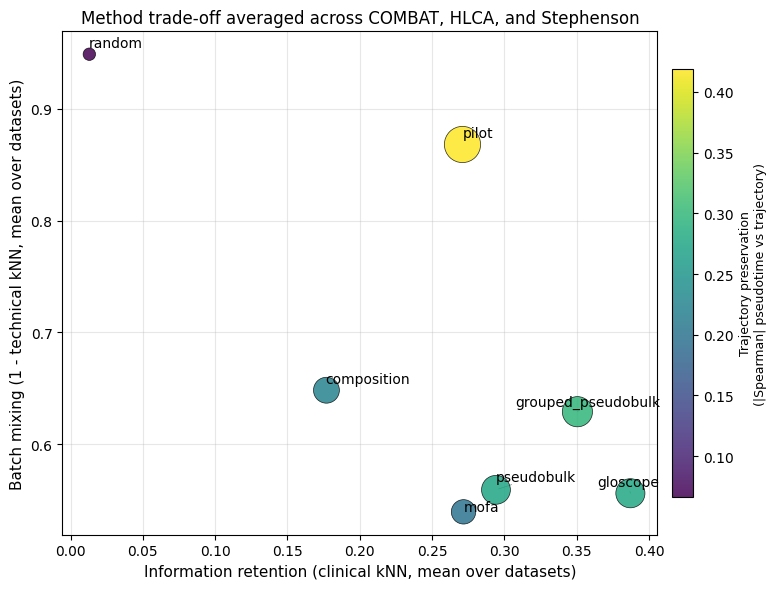

In [80]:
from matplotlib.lines import Line2D

# Best-effort label placement that avoids overlap: try adjustText if available,
# otherwise fall back to simple per-point offsets that we tune manually.
try:
    from adjustText import adjust_text  # noqa: F401
    HAS_ADJUSTTEXT = True
except ImportError:
    HAS_ADJUSTTEXT = False

fig, ax = plt.subplots(figsize=(8, 6))

# Marker size scaled by trajectory; colour mirrors size for redundancy
traj = cross_summary["Trajectory"].fillna(0)
sizes = 80 + 600 * (traj - traj.min()) / max(traj.max() - traj.min(), 1e-6)
colors = traj.values

sc = ax.scatter(
    cross_summary["Information retention"],
    cross_summary["Batch mixing"],
    s=sizes,
    c=colors,
    cmap="viridis",
    alpha=0.85,
    edgecolor="black",
    linewidth=0.5,
    zorder=3,
)

texts = []
for method, row in cross_summary.iterrows():
    texts.append(ax.text(
        row["Information retention"], row["Batch mixing"], method,
        fontsize=10, ha="left", va="bottom", zorder=4,
    ))

if HAS_ADJUSTTEXT:
    adjust_text(texts, ax=ax, only_move={"text": "xy"},
                arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

cbar = plt.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label("Trajectory preservation\n(|Spearman| pseudotime vs trajectory)", fontsize=9)

ax.set_xlabel("Information retention (clinical kNN, mean over datasets)", fontsize=11)
ax.set_ylabel("Batch mixing (1 - technical kNN, mean over datasets)", fontsize=11)
ax.set_title("Method trade-off averaged across COMBAT, HLCA, and Stephenson", fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


### Runtime per method per dataset (seconds)


In [81]:
runtime_table = pd.DataFrame(runtimes).round(1)
runtime_table["mean"] = runtime_table.mean(axis=1).round(1)
runtime_table.sort_values("mean")


,combat,hlca,stephenson,mean
pilot,0.0,NaN,NaN,0.0
random,0.0,0.0,0.1,0.0
pseudobulk,0.2,0.9,0.2,0.4
composition,0.2,0.8,0.4,0.5
grouped_pseudobulk,44.7,0.0,0.0,14.9
gloscope,77.1,205.7,31.1,104.6
mofa,38.0,578.2,140.1,252.1


Reading the scatter: top-right = best on both criteria. Marker size + colour encode the trajectory score, so a large bright marker in the top-right is a method that captures clinical signal, ignores technical artefacts, *and* preserves the disease trajectory. The runtime table above shows what that costs you in compute.


## Other methods and tutorials

We covered Pseudobulk, GroupedPseudobulk, CellGroupComposition, PILOT, MOFA, GloScope (Python), and a RandomVector baseline. `patpy` also ships:

- **`patpy.tl.MrVI`** — deep generative model conditioned on `sample_key` (and optionally `batch_key`). Best on a CUDA GPU; the torch wheels need to match the system NVIDIA driver version, otherwise it crashes at training time.
- **`patpy.tl.SCPoli`** — conditional VAE that learns a per-sample prototype, batch-aware by construction. Needs `pip install patpy[scpoli]` and (currently) an `anndata < 0.12` env because of how `scarches` imports.
- **`patpy.tl.DiffusionEarthMoverDistance`** — diffusion EMD over composition. Needs `pip install patpy[diffusionemd]` and `scikit-learn < 1.5` for the underlying `DiffusionEMD` package.
- **`patpy.tl.PhEMD`** — pure Python EMD with phenotype trees.
- **`patpy.tl.WassersteinTSNE`** — Wasserstein distances + t-SNE on top.
- **`patpy.tl.GloScope`** — R-based canonical implementation; deeper coverage in [`sources_of_variation_with_gloscope.ipynb`](./sources_of_variation_with_gloscope.ipynb).

Related tutorials:

- [`representation_methods_example.ipynb`](./representation_methods_example.ipynb) — another walkthrough of representation methods on COMBAT.
- [`sources_of_variation_with_gloscope.ipynb`](./sources_of_variation_with_gloscope.ipynb) — deep-dive on GloScope, including the R setup.
- [`supervised_methods_example.ipynb`](./supervised_methods_example.ipynb) — supervised counterparts (MixMIL, PULSAR, PaSCient).
- [`differential_analysis.ipynb`](./differential_analysis.ipynb) — once you have a representation, where to go next.

In the [SPARE benchmark](https://github.com/lueckenlab/SPARE/tree/feature/viash_nextflow_pipeline), GloScope was the best performer overall. The conda env file at [`envs/gloscope.yaml`](https://github.com/lueckenlab/patpy/blob/main/envs/gloscope.yaml) is the simplest way to set up its R dependencies.
